# Прогнозирование дневного сальдо ликвидности банка

## Описание проекта

Целью проекта является построение модели прогнозирования дневного сальдо ликвидности банка.

Целевая переменная определяется следующим образом:

$$
Сальдо_t = Доход_t - Расход_t
$$

где:
- Доход — входящие денежные потоки,
- Расход — исходящие денежные потоки,
- Сальдо — итоговое значение ликвидности.

---

# Постановка задачи

В рамках проекта исследуются два подхода к прогнозированию:

1. Прямое прогнозирование сальдо
2. Отдельное прогнозирование доходов и расходов с последующим вычислением сальдо

Качество обоих подходов сравнивается на временной выборке.

---

# Описание данных

Датасет содержит исторические дневные наблюдения, связанные с потоками ликвидности банка:
- доходы,
- расходы,
- сальдо,
- временные характеристики ряда.

В ходе исследования анализируются:
- тренд,
- сезонность,
- автокорреляция,
- стационарность,
- выбросы,
- возможные структурные изменения ряда.

---

# Цель прогнозирования

Основной задачей проекта является прогнозирование значения сальдо ликвидности на следующий день.

Задача рассматривается как задача регрессии временного ряда.

---

# Метрика качества

В качестве основной метрики качества используется средняя абсолютная ошибка:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat y_i|
$$

где:
- $y_i$ — истинное значение,
- $\hat y_i$ — прогноз модели.

Метрика MAE выбрана в соответствии с бизнес-требованием, так как техническое задание напрямую ограничивает абсолютную ошибку прогноза.

Согласно техническому заданию:
- абсолютная ошибка прогноза должна быть не более 0.42.

---

# Разделение данных и стратегия валидации

Так как данные являются временным рядом, стандартное случайное разделение выборки использовать нельзя из-за риска утечки информации из будущего.

Для оценки качества моделей используется:
- хронологическое разделение данных,
- перекрестная проверка временных рядов (TimeSeriesSplit).

Основные принципы:
- обучение производится только на прошлых наблюдениях,
- тестирование проводится только на будущих данных,
- порядок наблюдений во времени сохраняется.

---

# Исследуемые модели

В рамках проекта рассматриваются несколько групп моделей.

## Бейзлайн
- Прогноз средним значением

## Авторегрессионные модели
- ARIMA
- SARIMA

## Модели машинного обучения
- Random Forest
- CatBoost

---

# Генерация признаков

Для моделей машинного обучения временной ряд преобразуется в задачу обучения с учителем с использованием:
- лаговых признаков,
- скользящих статистик,
- календарных признаков,
- сезонных признаков.

---

# Отбор признаков

Проект включает модуль автоматического отбора признаков.

Сравниваются методы из различных категорий.

## Фильтрационные методы
- Корреляционный анализ

## Встроенные методы
- Lasso-регрессия

## Оберточные методы
- Permutation Importance

Как минимум один из методов учитывает нелинейные зависимости между признаками и целевой переменной.

---

# Оптимизация гиперпараметров

Для моделей реализован автоматический подбор гиперпараметров с оптимизацией целевой метрики.

Для оптимизации используется:
- Optuna,
- оптимизация по MAE.

---

# Контроль разладки и переобучение модели

Пайплайн включает:
- мониторинг изменения распределения данных,
- мониторинг деградации качества модели,
- стратегию автоматического переобучения.

Переобучение модели выполняется:
- периодически,
- а также при обнаружении ухудшения качества прогноза.

In [15]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose

from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit

In [2]:
%config InlineBackend.figure_format = 'retina'
sns.set_style('darkgrid')

plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
# Импорт модулей
from data_loader import load_data
from drift import detect_changepoints
from features import create_features, get_features_target
from tuning import tune_random_forest, tune_catboost

from model import (
    run_arima,
    run_mean_baseline,
    run_sarima,
    run_random_forest,
    run_catboost
)

from feature_selection import (
    get_feature_importance,
    get_permutation_importance,
    select_by_correlation,
    select_by_lasso,
    select_by_permutation,
    evaluate_selected_features,
    average_kuncheva,
    select_by_mutual_information
)

from parser import save_key_rate_to_excel

# Обработка данных и EDA

In [4]:
data = load_data("Project 1_2024.xlsx")

In [5]:
df = data.copy()

df["Date"] = pd.to_datetime(df["Date"]).dt.date
df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
df["Date"] = pd.to_datetime(df["Date"])

# Убираем выходные
df = df[df["Date"].dt.dayofweek < 5].copy()
df = df.reset_index(drop=True)


In [ ]:
# Проверка данных
print("=" * 60)
print("Диапазон дат")
print("=" * 60)

print(f"Минимальная дата: {df['Date'].min()}")
print(f"Максимальная дата: {df['Date'].max()}")

print("\n" + "=" * 60)
print("Размер датасета")
print("=" * 60)

print(df.shape)

print("\n" + "=" * 60)
print("Информация о данных")
print("=" * 60)

print(df.info())

print("\n" + "=" * 60)
print("Пропуски")
print("=" * 60)

print(df.isna().sum())

print("\n" + "=" * 60)
print("Дубликаты")
print("=" * 60)

print(df.duplicated().sum())

print("\n" + "=" * 60)
print("Описательные статистики")
print("=" * 60)

display(df.describe())
display(df.info())

Диапазон дат
Минимальная дата: 2017-01-09 00:00:00
Максимальная дата: 2021-03-31 00:00:00

Размер датасета
(1103, 4)

Информация о данных
<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1103 non-null   datetime64[us]
 1   Income   1103 non-null   float64       
 2   Outcome  1103 non-null   float64       
 3   Balance  1103 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 34.6 KB
None

Пропуски
Date       0
Income     0
Outcome    0
Balance    0
dtype: int64

Дубликаты
0

Описательные статистики


,Date,Income,Outcome,Balance
count,1103,1103.000000,1103.000000,1103.000000
mean,2019-02-18 14:25:33.998186,1.511109,1.579227,-0.068175
min,2017-01-09 00:00:00,0.000000,0.000000,-2.514887
25%,2018-01-29 12:00:00,1.250536,1.259074,-0.219588
50%,2019-02-19 00:00:00,1.514199,1.527366,-0.032563
75%,2020-03-10 12:00:00,1.777538,1.896040,0.112847
max,2021-03-31 00:00:00,5.108775,5.003439,1.408863
std,NaN,0.579124,0.655543,0.343261


<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1103 non-null   datetime64[us]
 1   Income   1103 non-null   float64       
 2   Outcome  1103 non-null   float64       
 3   Balance  1103 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 34.6 KB


None

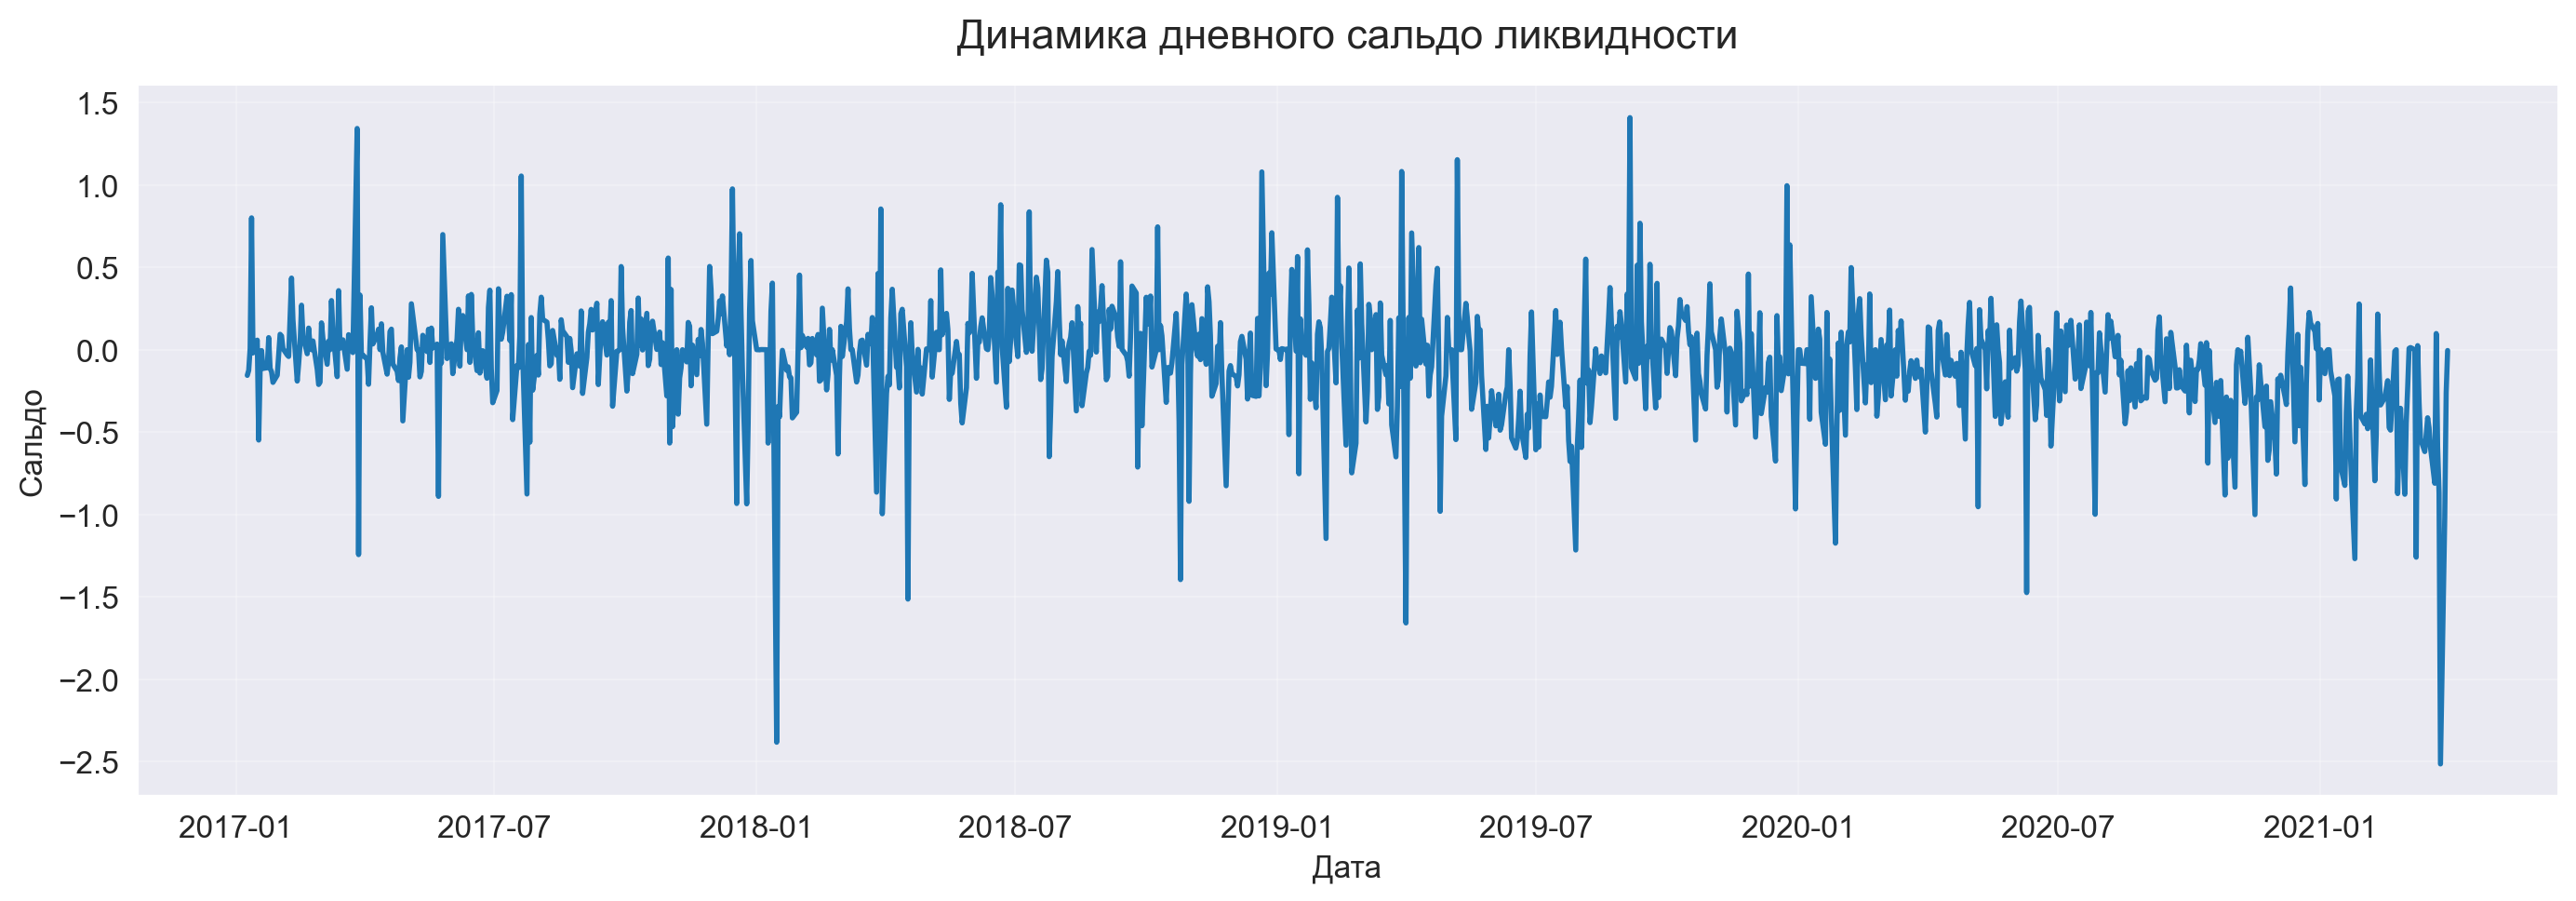

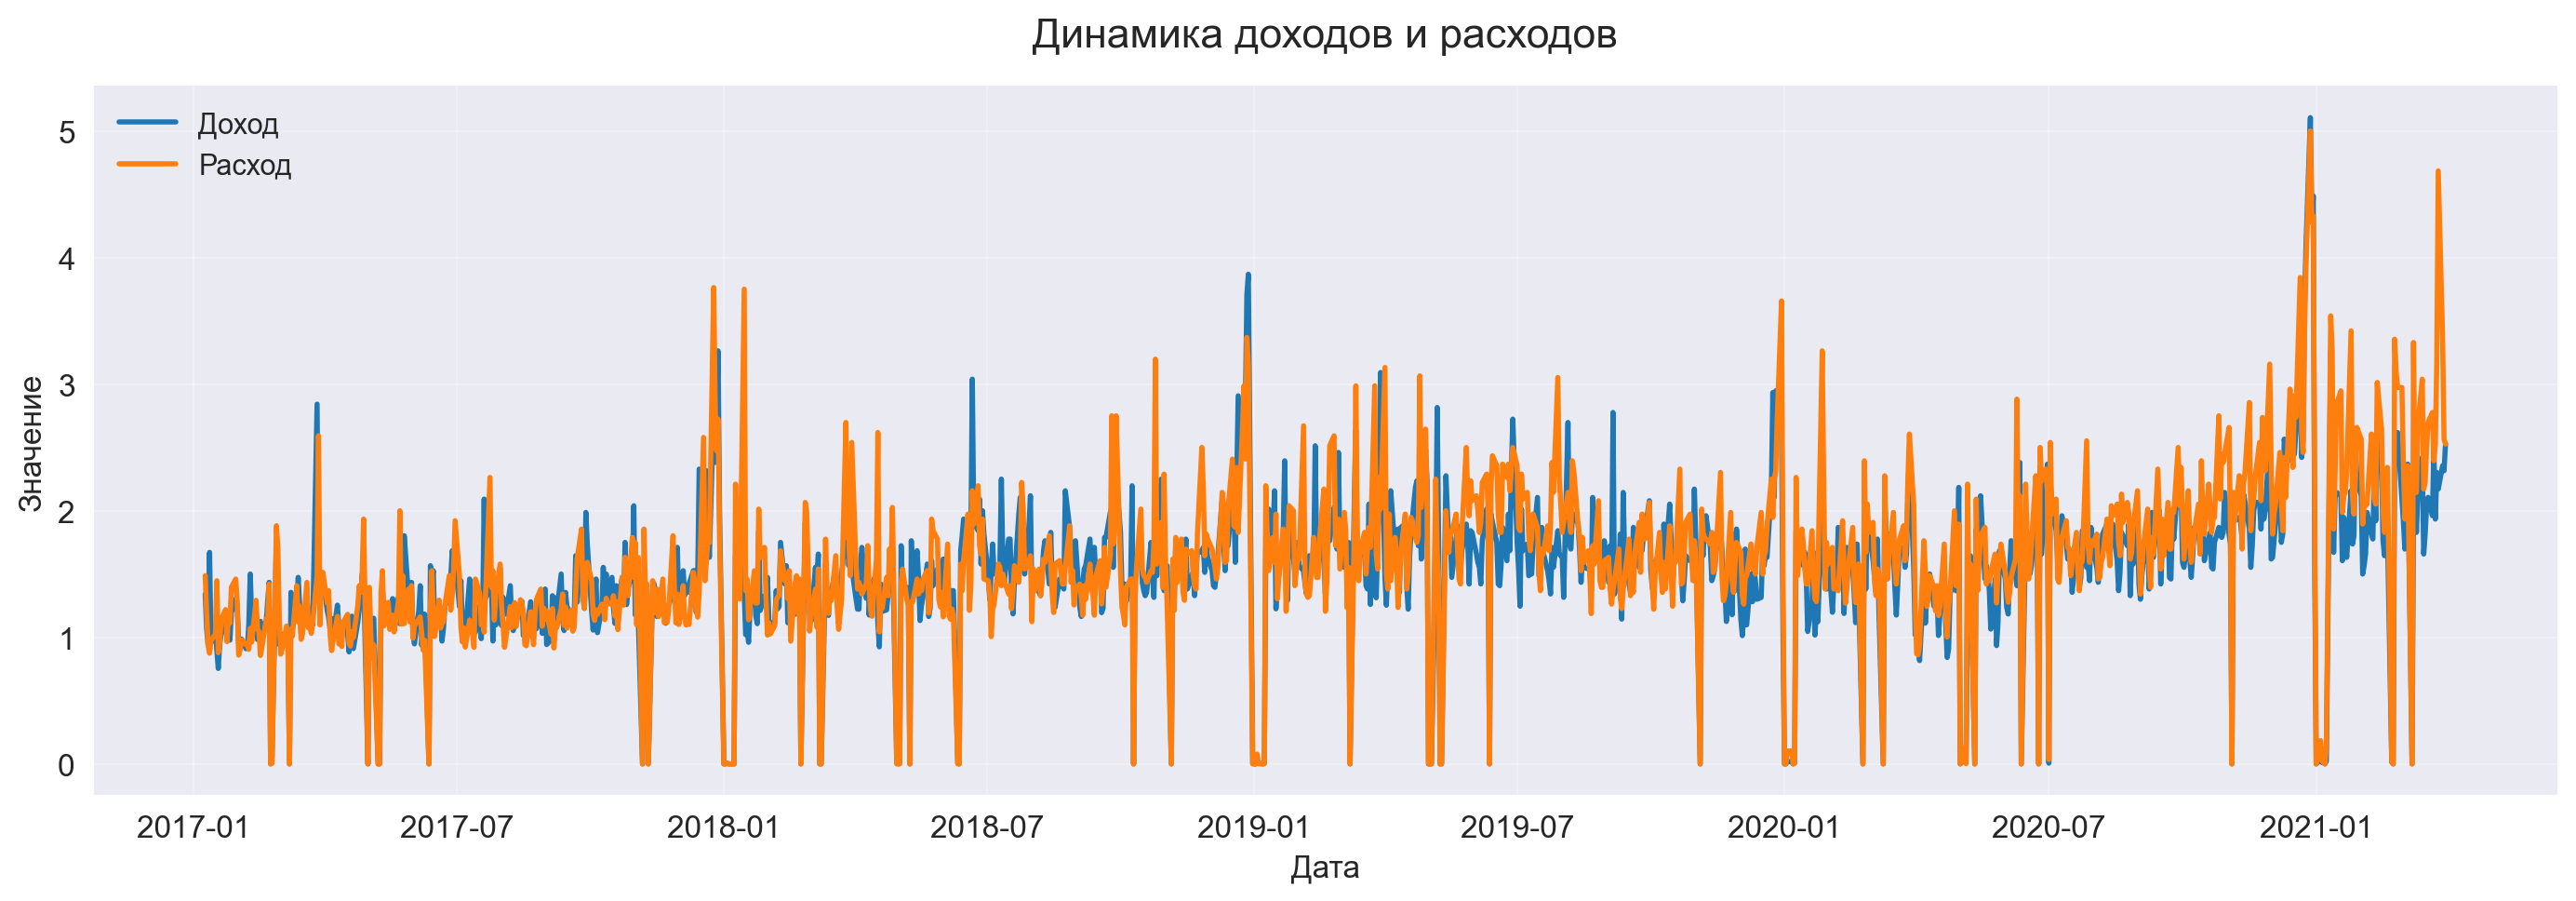

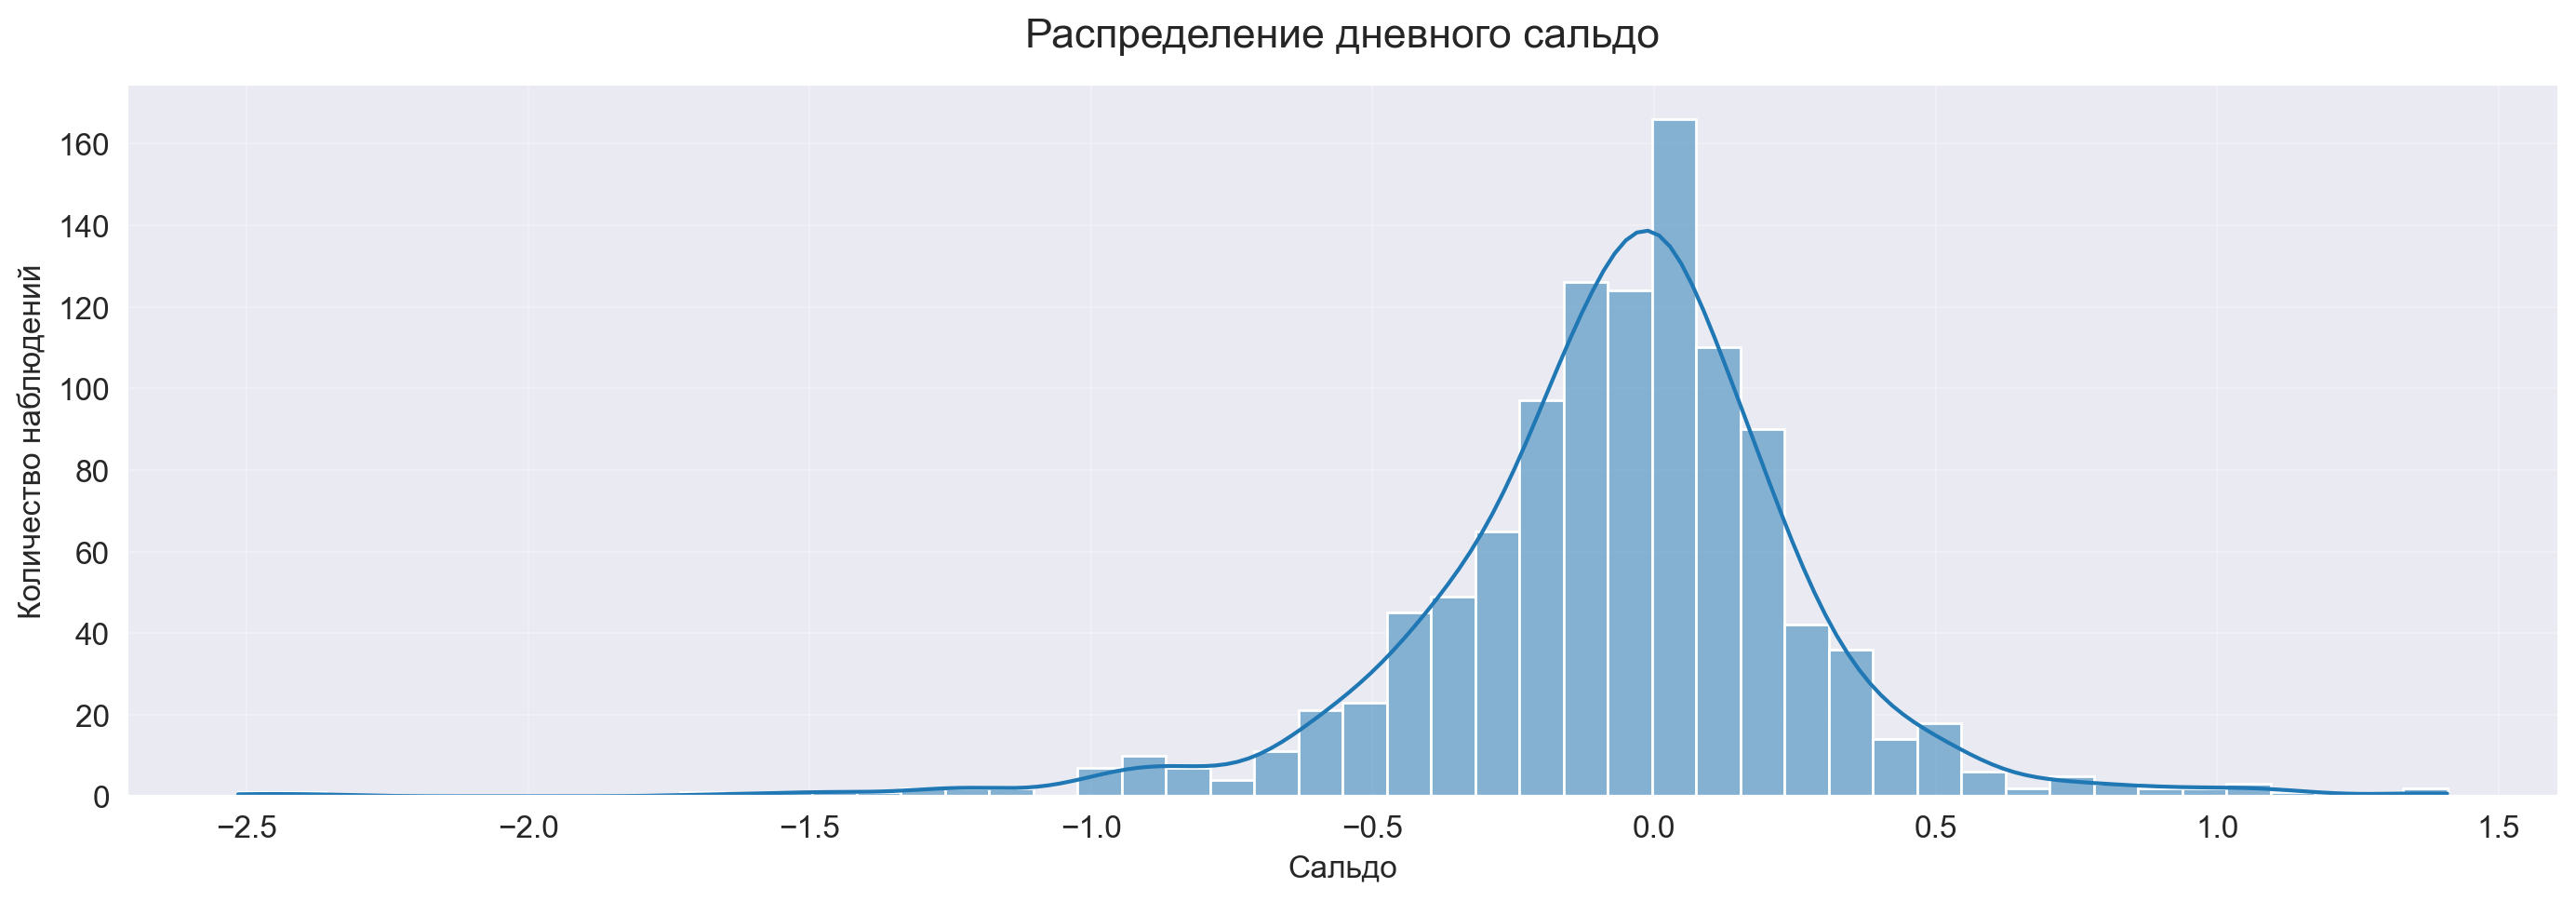

In [38]:
sns.lineplot(data=df, x="Date", y="Balance", linewidth=2)
plt.title("Динамика дневного сальдо ликвидности", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

sns.lineplot(data=df, x="Date", y="Income", linewidth=2, label="Доход")
sns.lineplot(data=df, x="Date", y="Outcome", linewidth=2, label="Расход")
plt.title("Динамика доходов и расходов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

sns.histplot(data=df, x="Balance", bins=50, kde=True)
plt.title("Распределение дневного сальдо", pad=15)
plt.xlabel("Сальдо")
plt.ylabel("Количество наблюдений")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

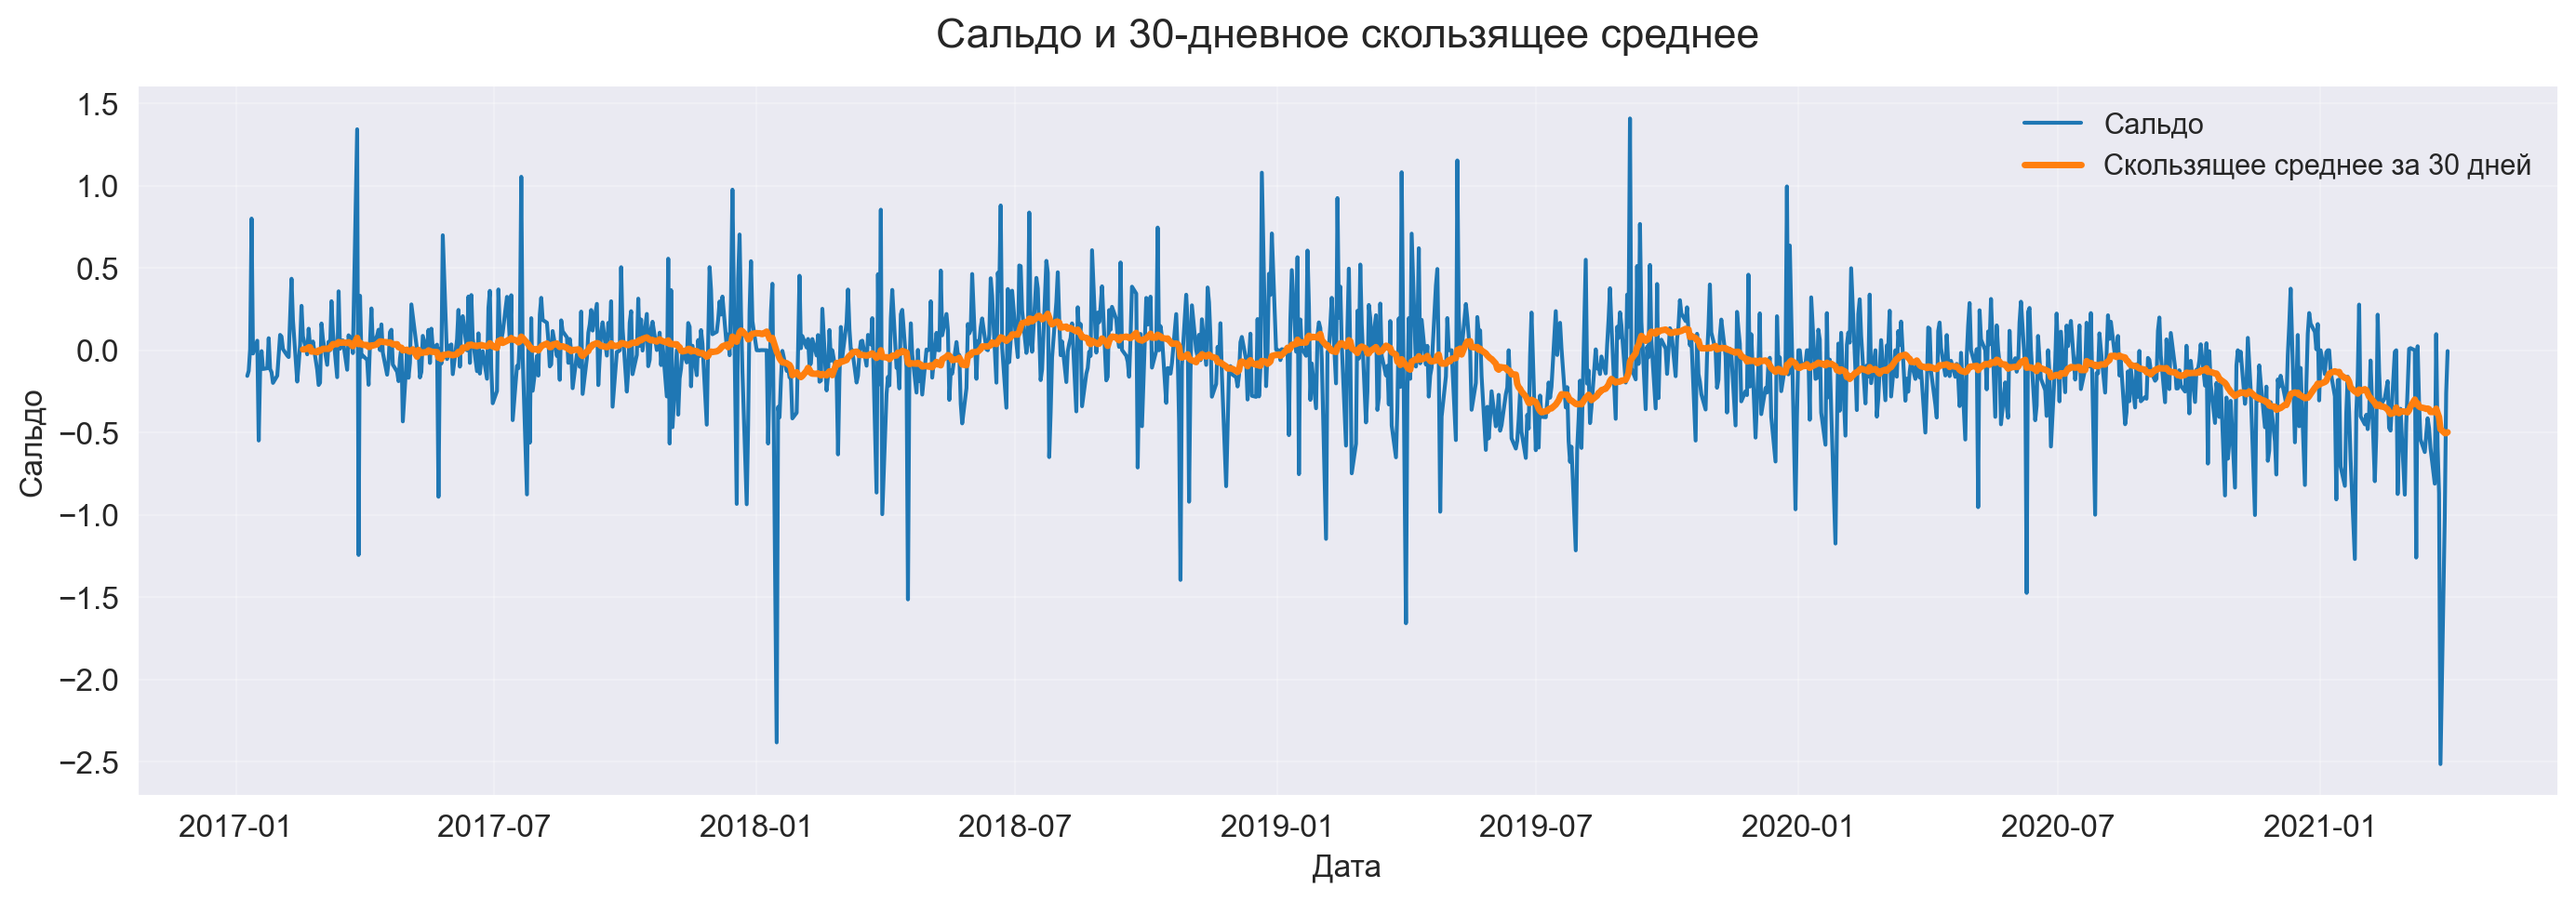

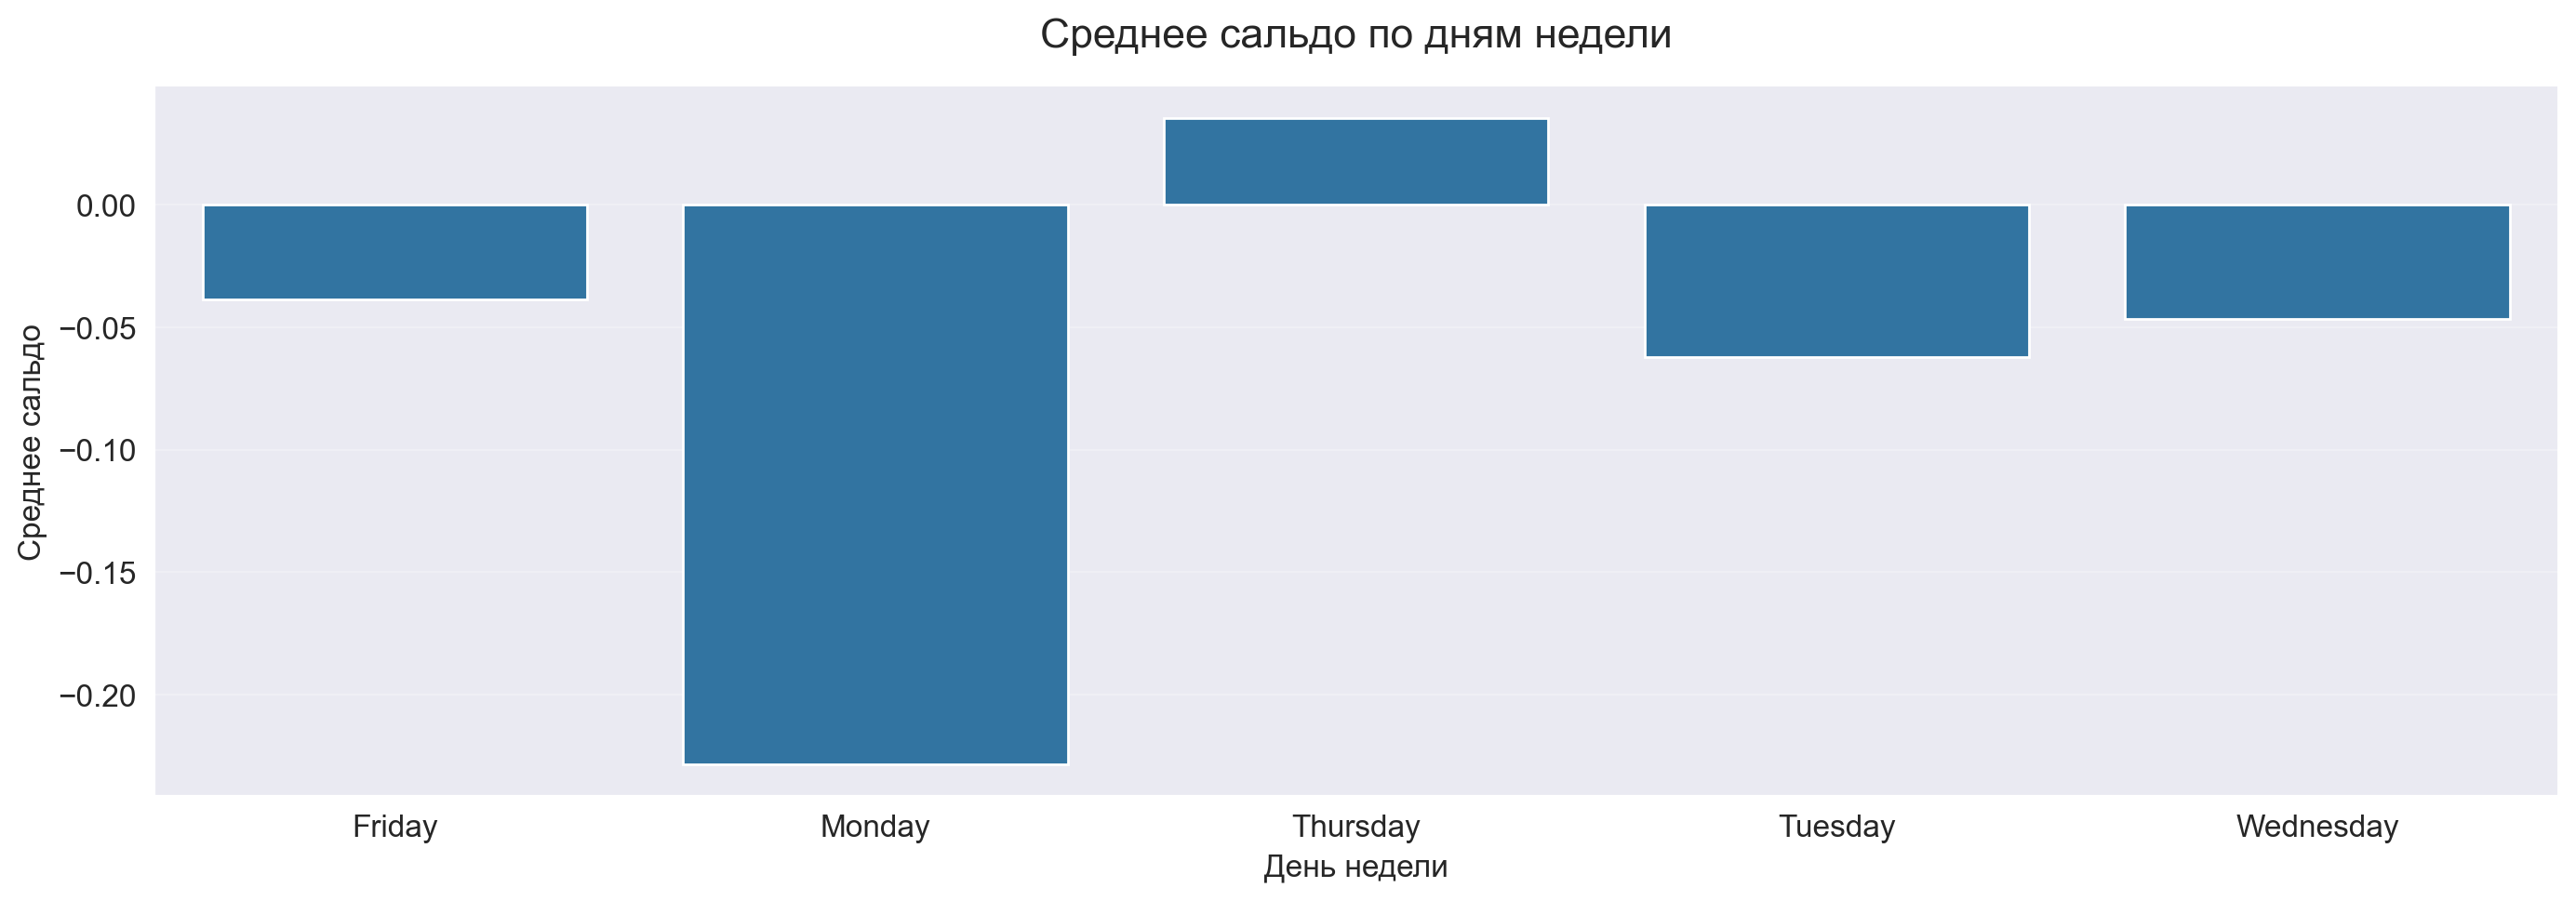

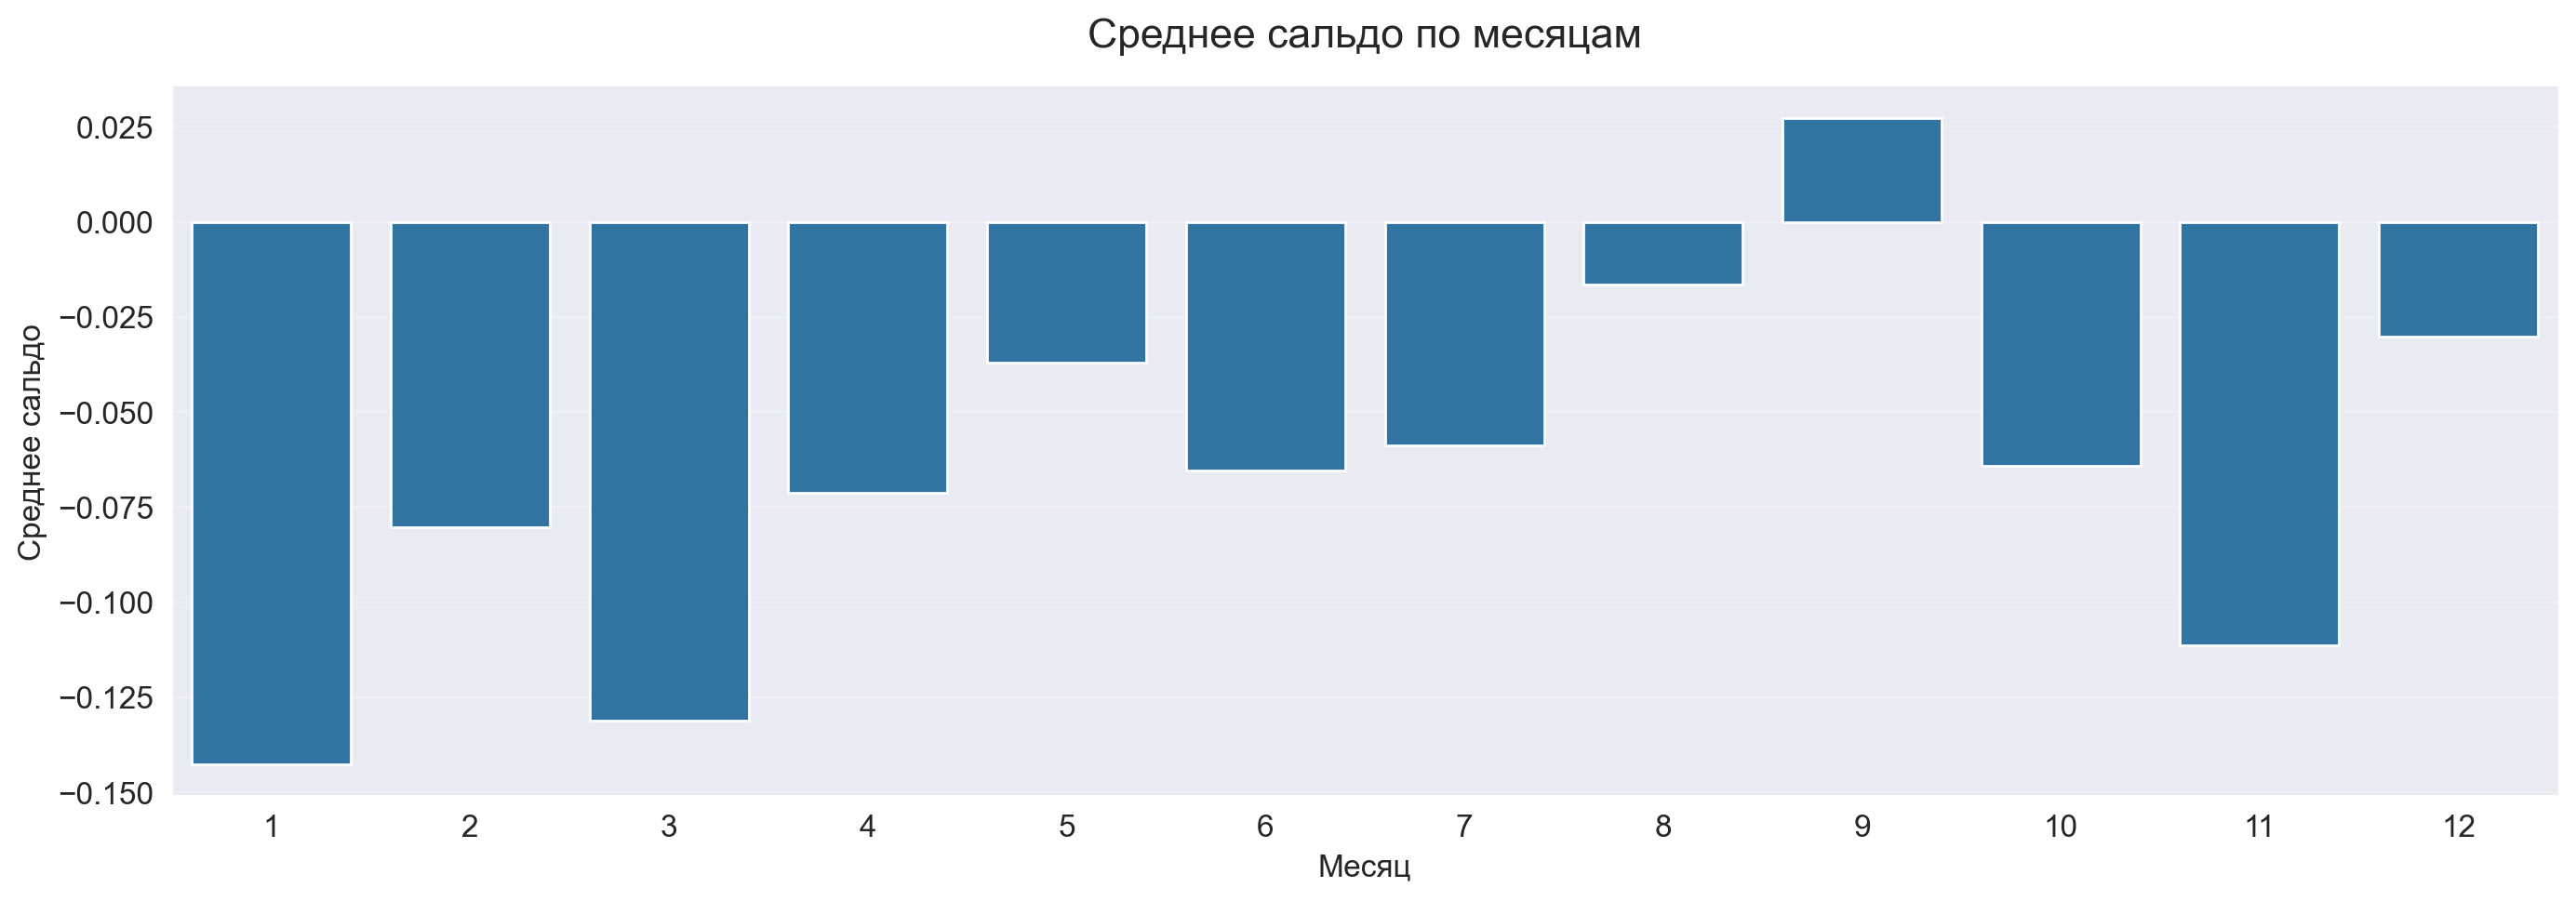

In [8]:
df["RollingMean30"] = df["Balance"].rolling(window=30).mean()

sns.lineplot(data=df, x="Date", y="Balance", linewidth=1.5, label="Сальдо")
sns.lineplot(data=df, x="Date", y="RollingMean30", linewidth=2.5, label="Скользящее среднее за 30 дней")
plt.title("Сальдо и 30-дневное скользящее среднее", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

df["DayOfWeek"] = df["Date"].dt.day_name()
weekday_stats = df.groupby("DayOfWeek", as_index=False)["Balance"].mean()

sns.barplot(data=weekday_stats, x="DayOfWeek", y="Balance")
plt.title("Среднее сальдо по дням недели", pad=15)
plt.xlabel("День недели")
plt.ylabel("Среднее сальдо")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


df["Month"] = df["Date"].dt.month
month_stats = df.groupby("Month", as_index=False)["Balance"].mean()

sns.barplot(data=month_stats, x="Month", y="Balance")
plt.title("Среднее сальдо по месяцам", pad=15)
plt.xlabel("Месяц")
plt.ylabel("Среднее сальдо")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Разладки
## Для обнаружения разладок применяется метод кумулятивных сумм

In [9]:
series = df.set_index("Date")["Balance"]

cusum_result, changepoints = detect_changepoints(
    series=series,
    threshold=5,
    drift=0.5
)

changepoints

DatetimeIndex(['2017-12-15', '2018-01-15', '2018-07-05', '2018-12-28',
               '2019-06-07', '2019-06-24', '2019-07-29', '2019-09-12',
               '2020-10-29', '2020-11-27', '2021-01-19', '2021-01-26',
               '2021-02-24', '2021-03-15', '2021-03-25', '2021-03-26'],
              dtype='datetime64[us]', name='Date', freq=None)

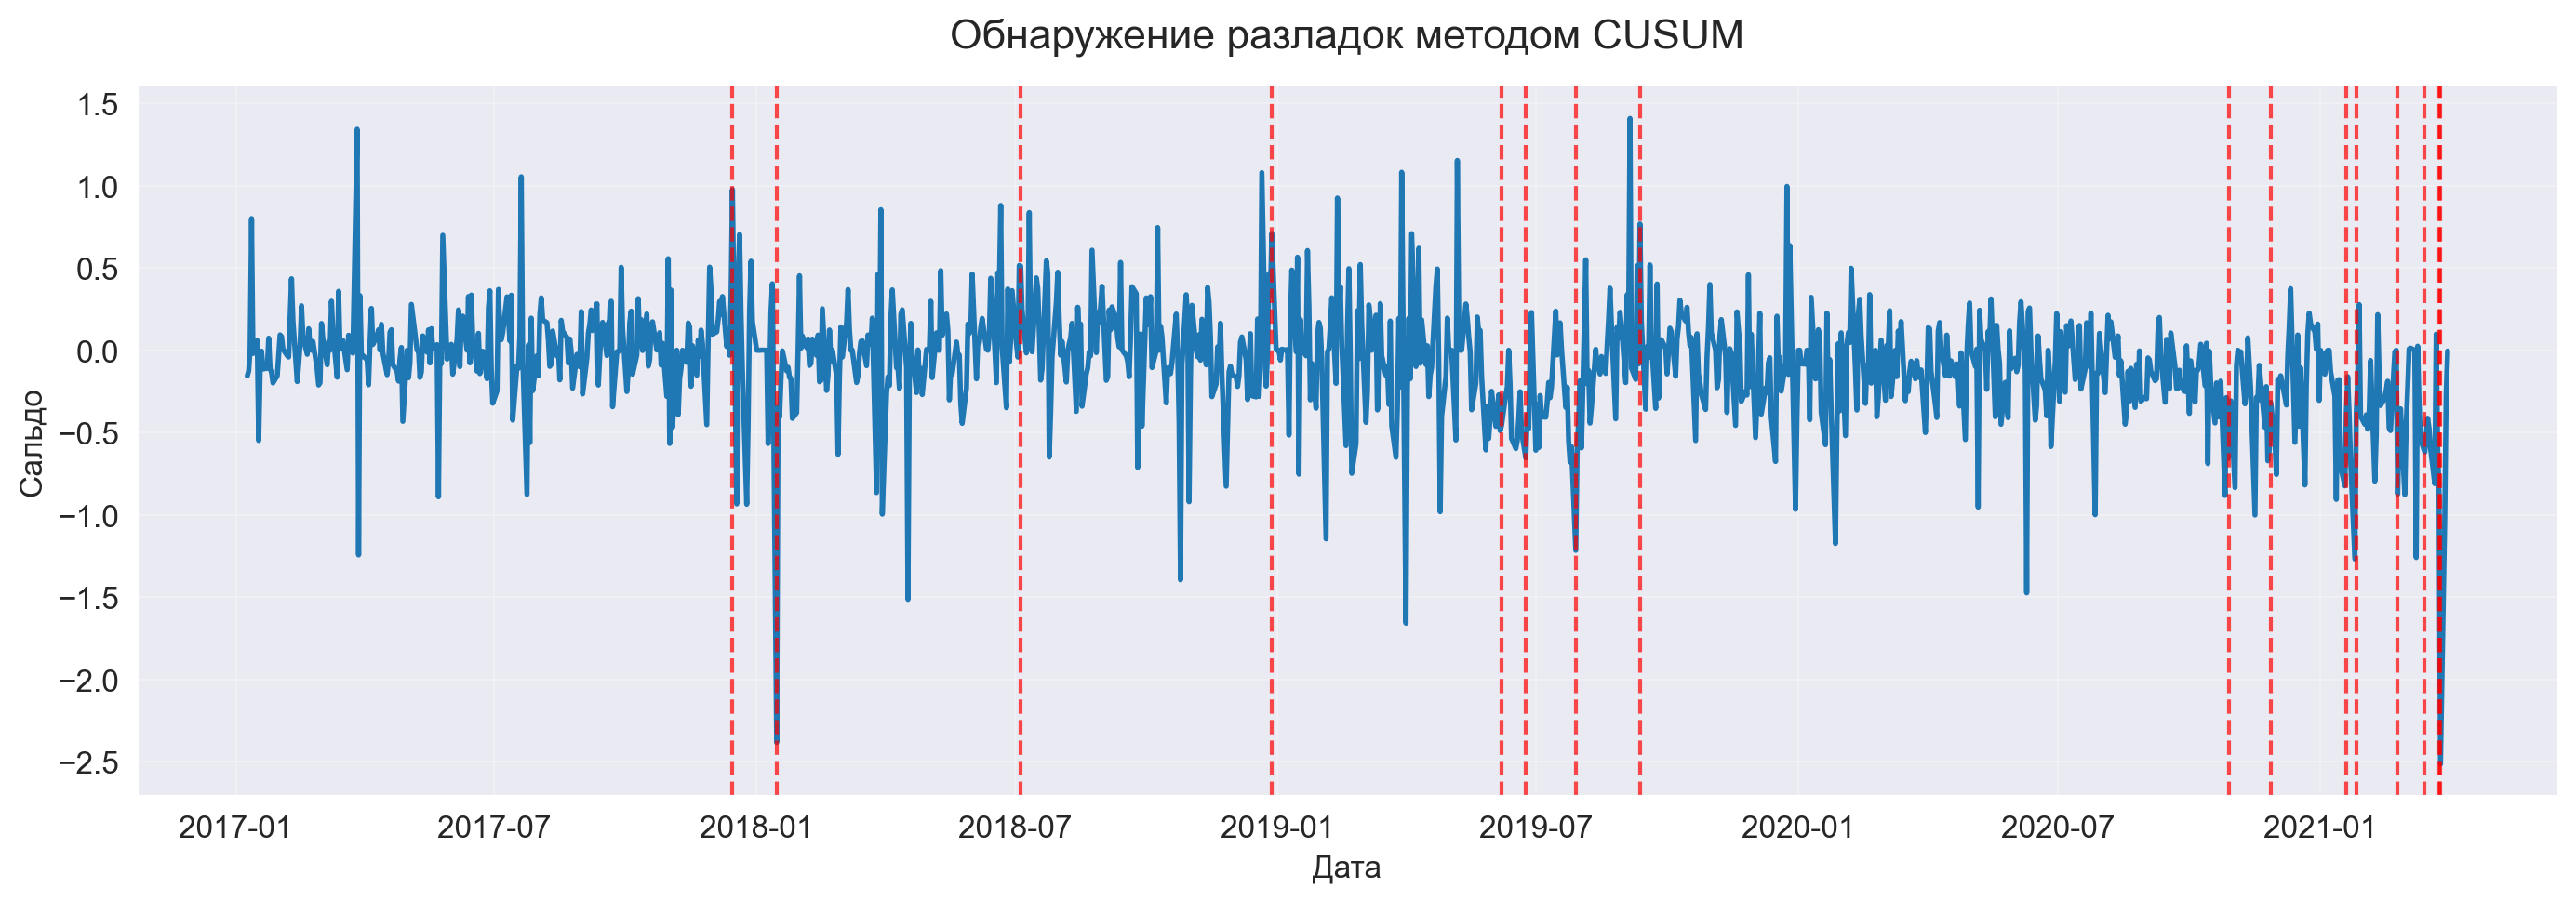

In [13]:
sns.lineplot(x=cusum_result.index, y=cusum_result["Value"], linewidth=2)

for point in changepoints:
    plt.axvline(x=point, linestyle="--", alpha=0.7, color="red")

plt.title("Обнаружение разладок методом CUSUM", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Метод CUSUM выявил ряд потенциальных точек изменения процесса.

### Визуальный анализ показал, что большинство обнаруженных событий связано с отдельными экстремальными наблюдениями, а не с устойчивым изменением статистических свойств ряда.

### Существенных структурных разладок, приводящих к смене режима функционирования процесса, обнаружено не было. Следовательно, временной ряд может рассматриваться как относительно однородный на рассматриваемом временном интервале.

# Авторегрессионные модели
## Проверяется стационарность ряда, возможность применимости моделей, подбор параметров

In [ ]:
# Анализ стационарности ряда
series = df.set_index("Date")["Balance"]
series = df.set_index("Date")["Balance"].dropna()
adf_result = adfuller(series)

print("ADF-тест")
print("-" * 40)
print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Ряд можно считать стационарным, дифференцирование может не потребоваться.")
else:
    print("Ряд нестационарен, рекомендуется использовать дифференцирование.")

ADF-тест
----------------------------------------
ADF statistic: -3.1544
p-value: 0.0228
Ряд можно считать стационарным, дифференцирование может не потребоваться.


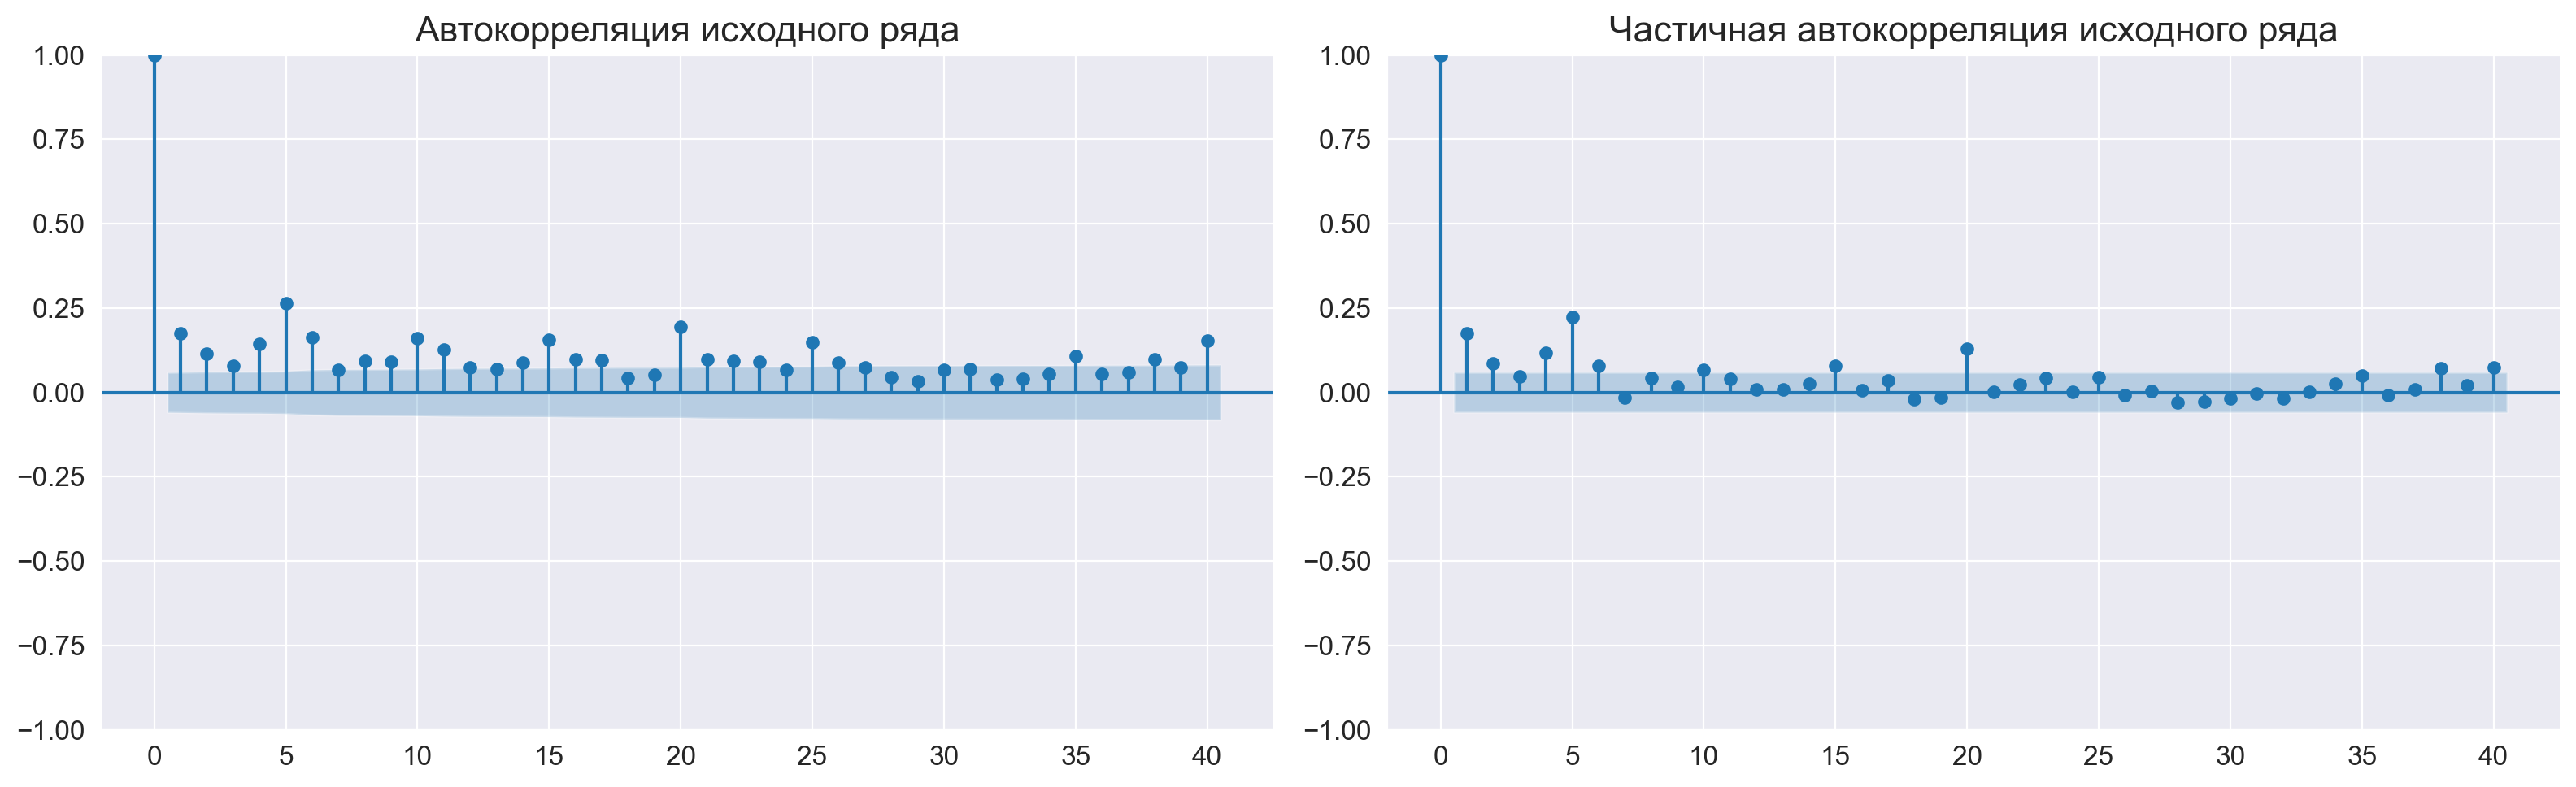

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(series, lags=40, ax=axes[0])

axes[0].set_title("Автокорреляция исходного ряда")

plot_pacf(series, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Частичная автокорреляция исходного ряда")

plt.tight_layout()
plt.show()

По левому графику можно понять, что q можно брать равным 1 или 2 \
По правому графику видно, что p стоит попробовать также равным 1 или 2 \
Ряд стационарен, поэтому d = 0 \
\
Итого получилась модель ARIMA(1, 0, 1)

## ARIMA

In [12]:
series = df.set_index("Date")["Balance"]

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(series))
train_idx, test_idx = splits[-1]

y_train = series.iloc[train_idx]
y_test = series.iloc[test_idx]

print(f"Размер обучающей выборки: {len(y_train)}")
print(f"Размер тестовой выборки: {len(y_test)}")
print("\nПериод обучения:")
print(y_train.index.min(), "-", y_train.index.max())
print("\nПериод тестирования:")
print(y_test.index.min(), "-", y_test.index.max())

Размер обучающей выборки: 920
Размер тестовой выборки: 183

Период обучения:
2017-01-09 00:00:00 - 2020-07-17 00:00:00

Период тестирования:
2020-07-20 00:00:00 - 2021-03-31 00:00:00


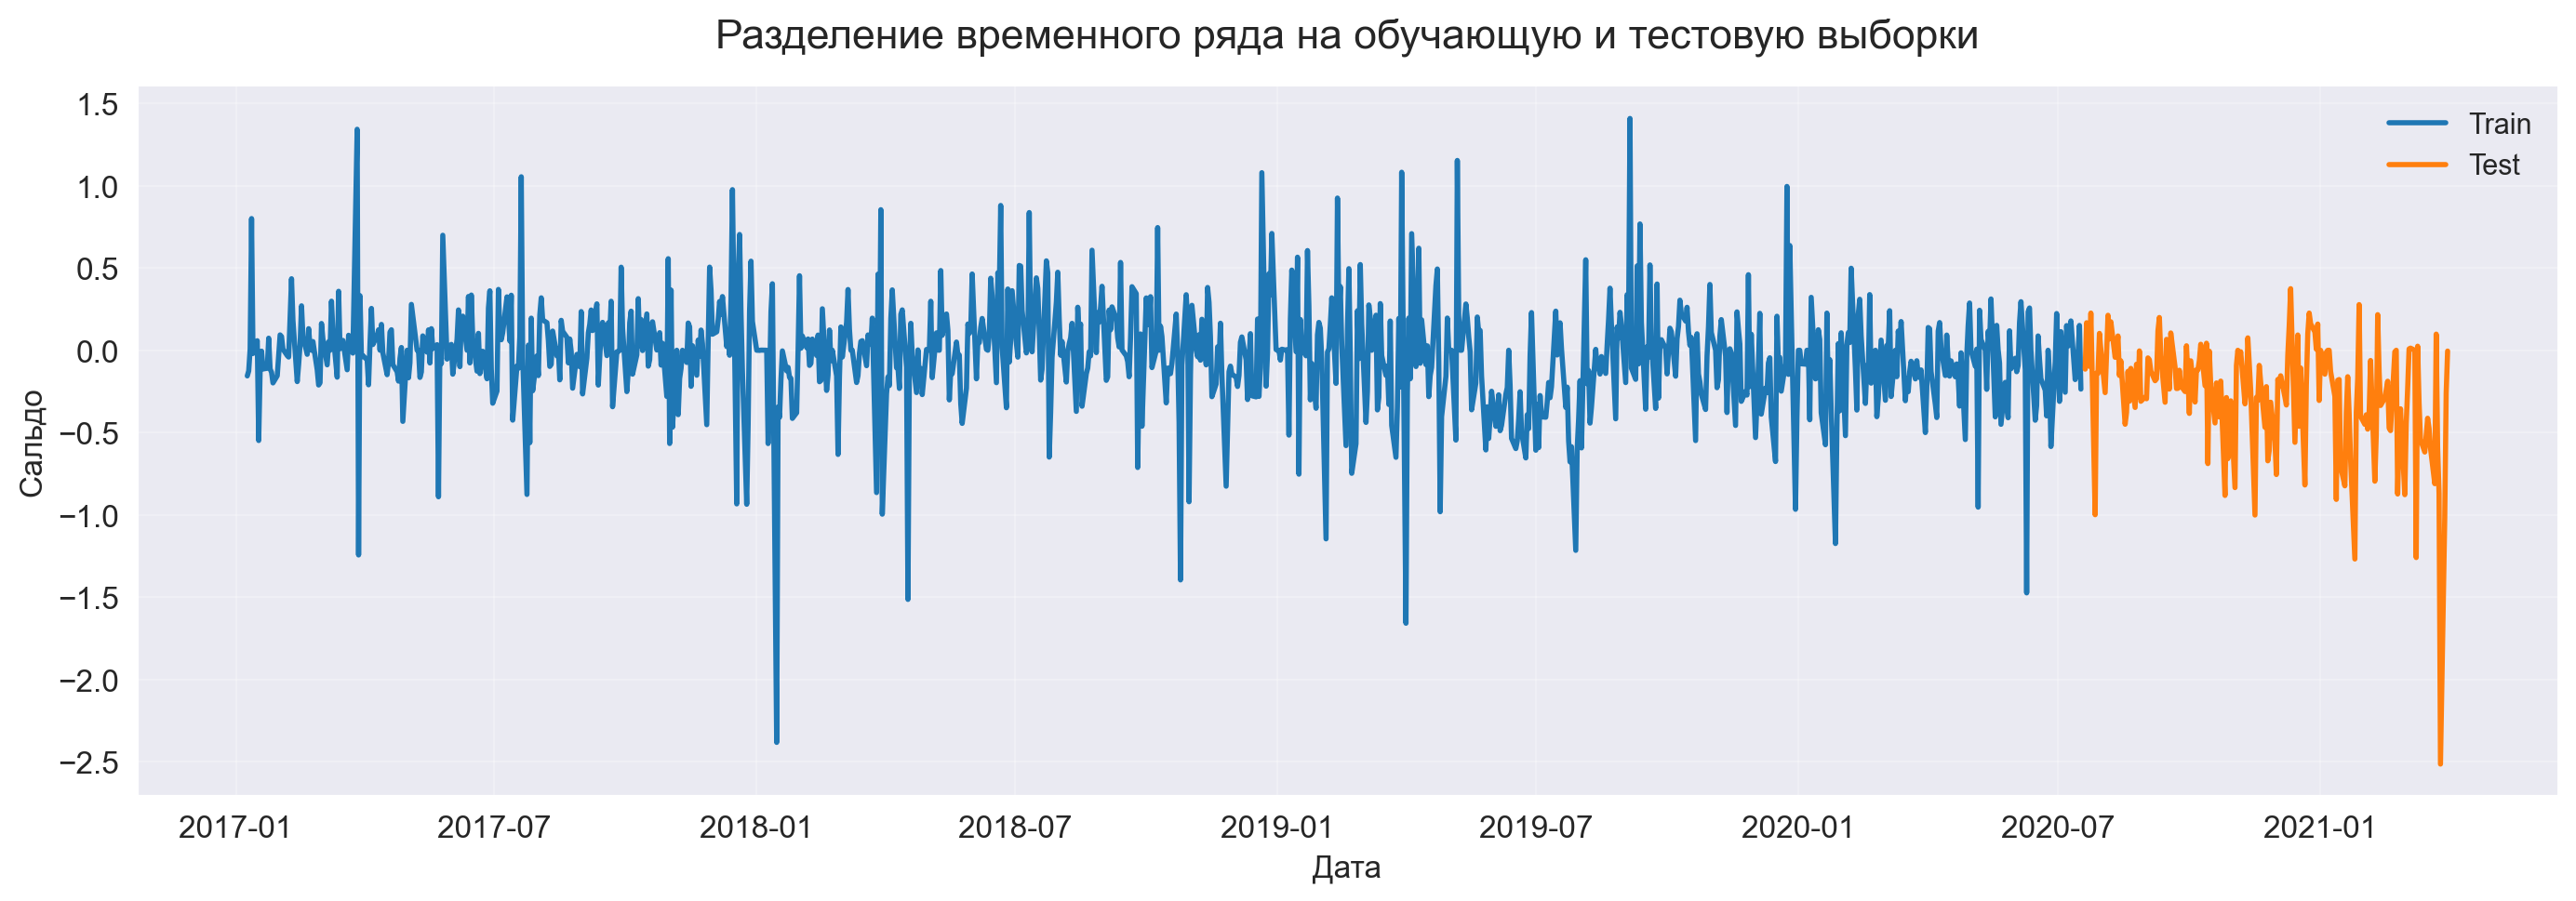

In [13]:
sns.lineplot(x=y_train.index, y=y_train.values, label="Train", linewidth=2)
sns.lineplot(x=y_test.index, y=y_test.values, label="Test", linewidth=2)
plt.title("Разделение временного ряда на обучающую и тестовую выборки", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [14]:
arima_model, arima_result, arima_metrics = run_arima(y_train=y_train, y_test=y_test, p=1, d=0, q=1)

arima_metrics

{'MAE': 0.2322531393005645}

Результат получается примерно одинаковый при других наборах p и q

# Сравнение с бейзлайном

In [15]:
baseline_result, baseline_metrics = run_mean_baseline(y_train=y_train, y_test=y_test)

print("Baseline MAE:")
print(baseline_metrics)

Baseline MAE:
{'MAE': 0.2806629547871521}


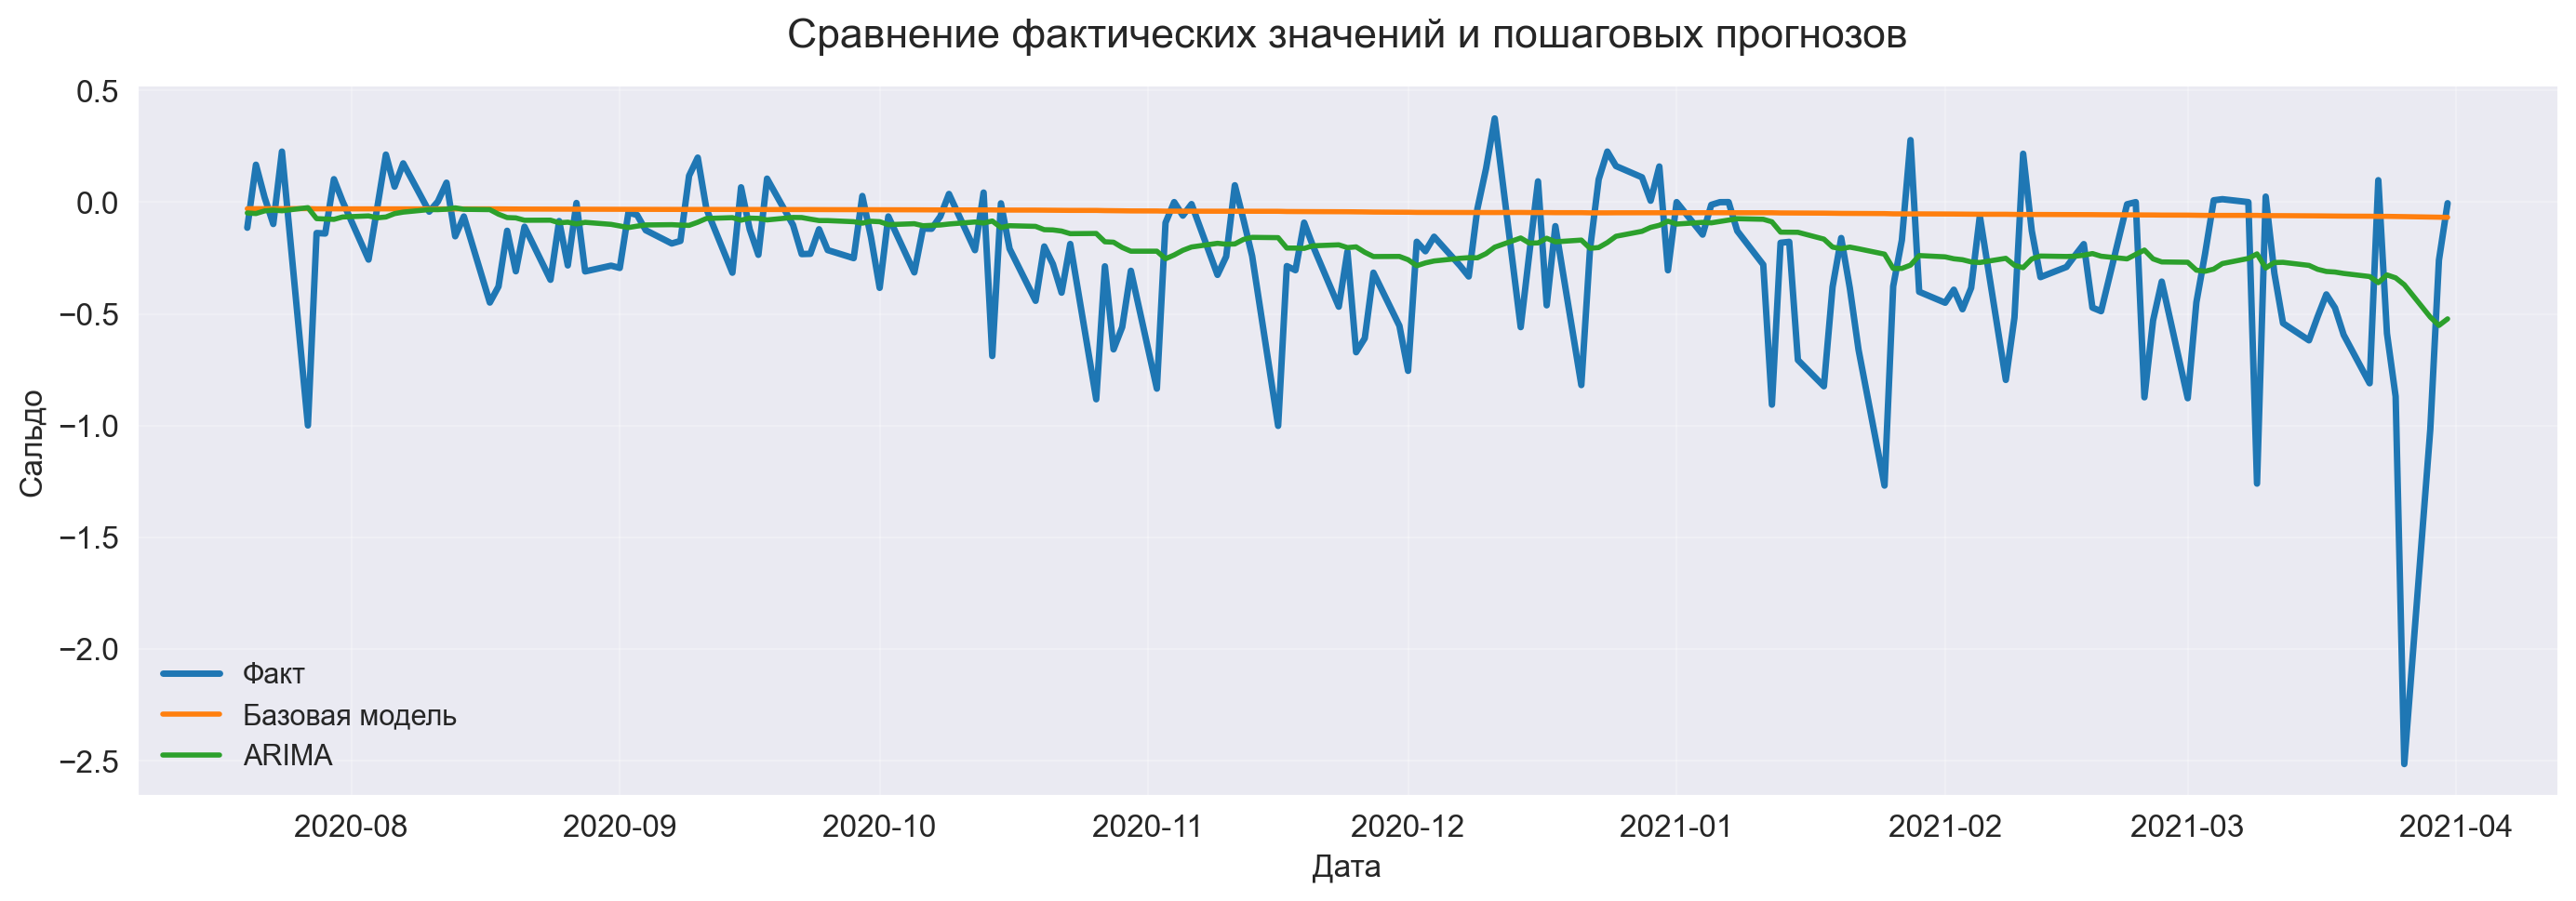

In [16]:
comparison_df = pd.DataFrame({
    "Факт": y_test.values,
    "Базовая модель": baseline_result["Predicted"].values,
    "ARIMA": arima_result["Predicted"].values
}, index=y_test.index)

sns.lineplot(x=comparison_df.index, y=comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=comparison_df.index, y=comparison_df["Базовая модель"], label="Базовая модель", linewidth=2)
sns.lineplot(x=comparison_df.index, y=comparison_df["ARIMA"], label="ARIMA", linewidth=2)
plt.title("Сравнение фактических значений и пошаговых прогнозов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Предсказание с помощью ARIMA получилось лучше бейзлайна
## Бейзлайн модель уже удовлетворяет условию заказчика

# SARIMA
## Проверяем наличие сезонности

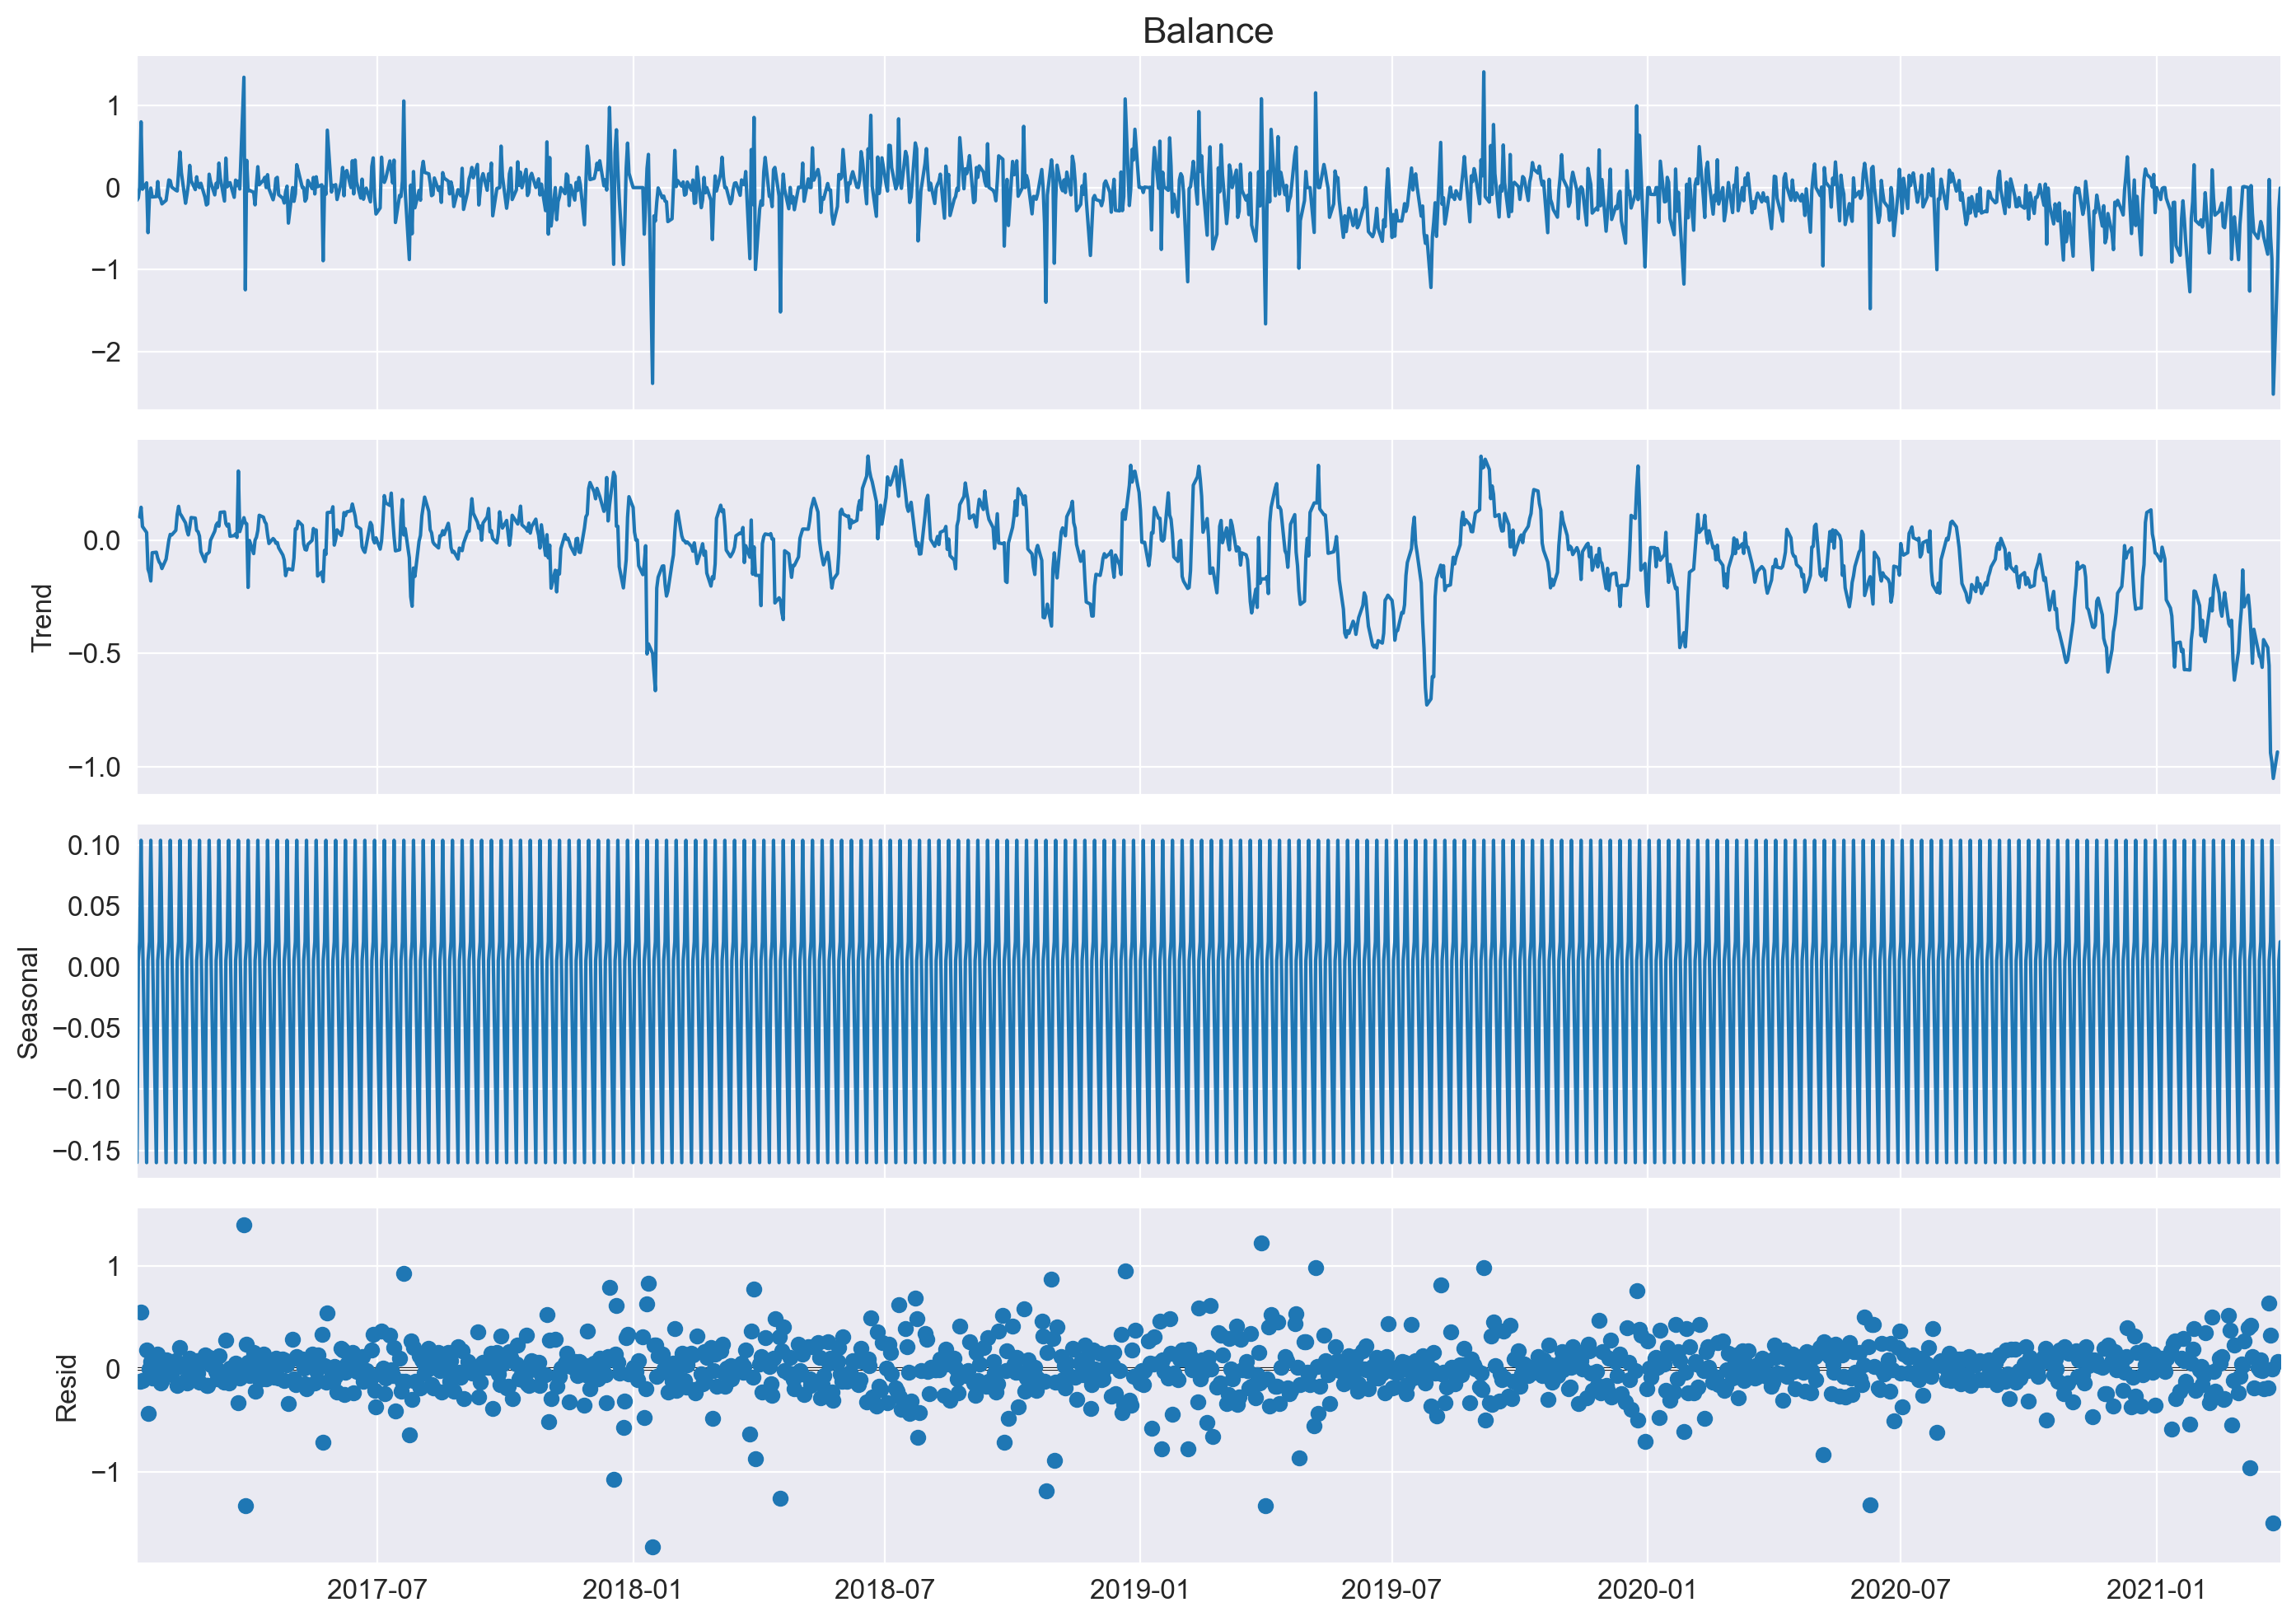

In [17]:
decomposition = seasonal_decompose(series, model="additive", period=5)

fig = decomposition.plot()

fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

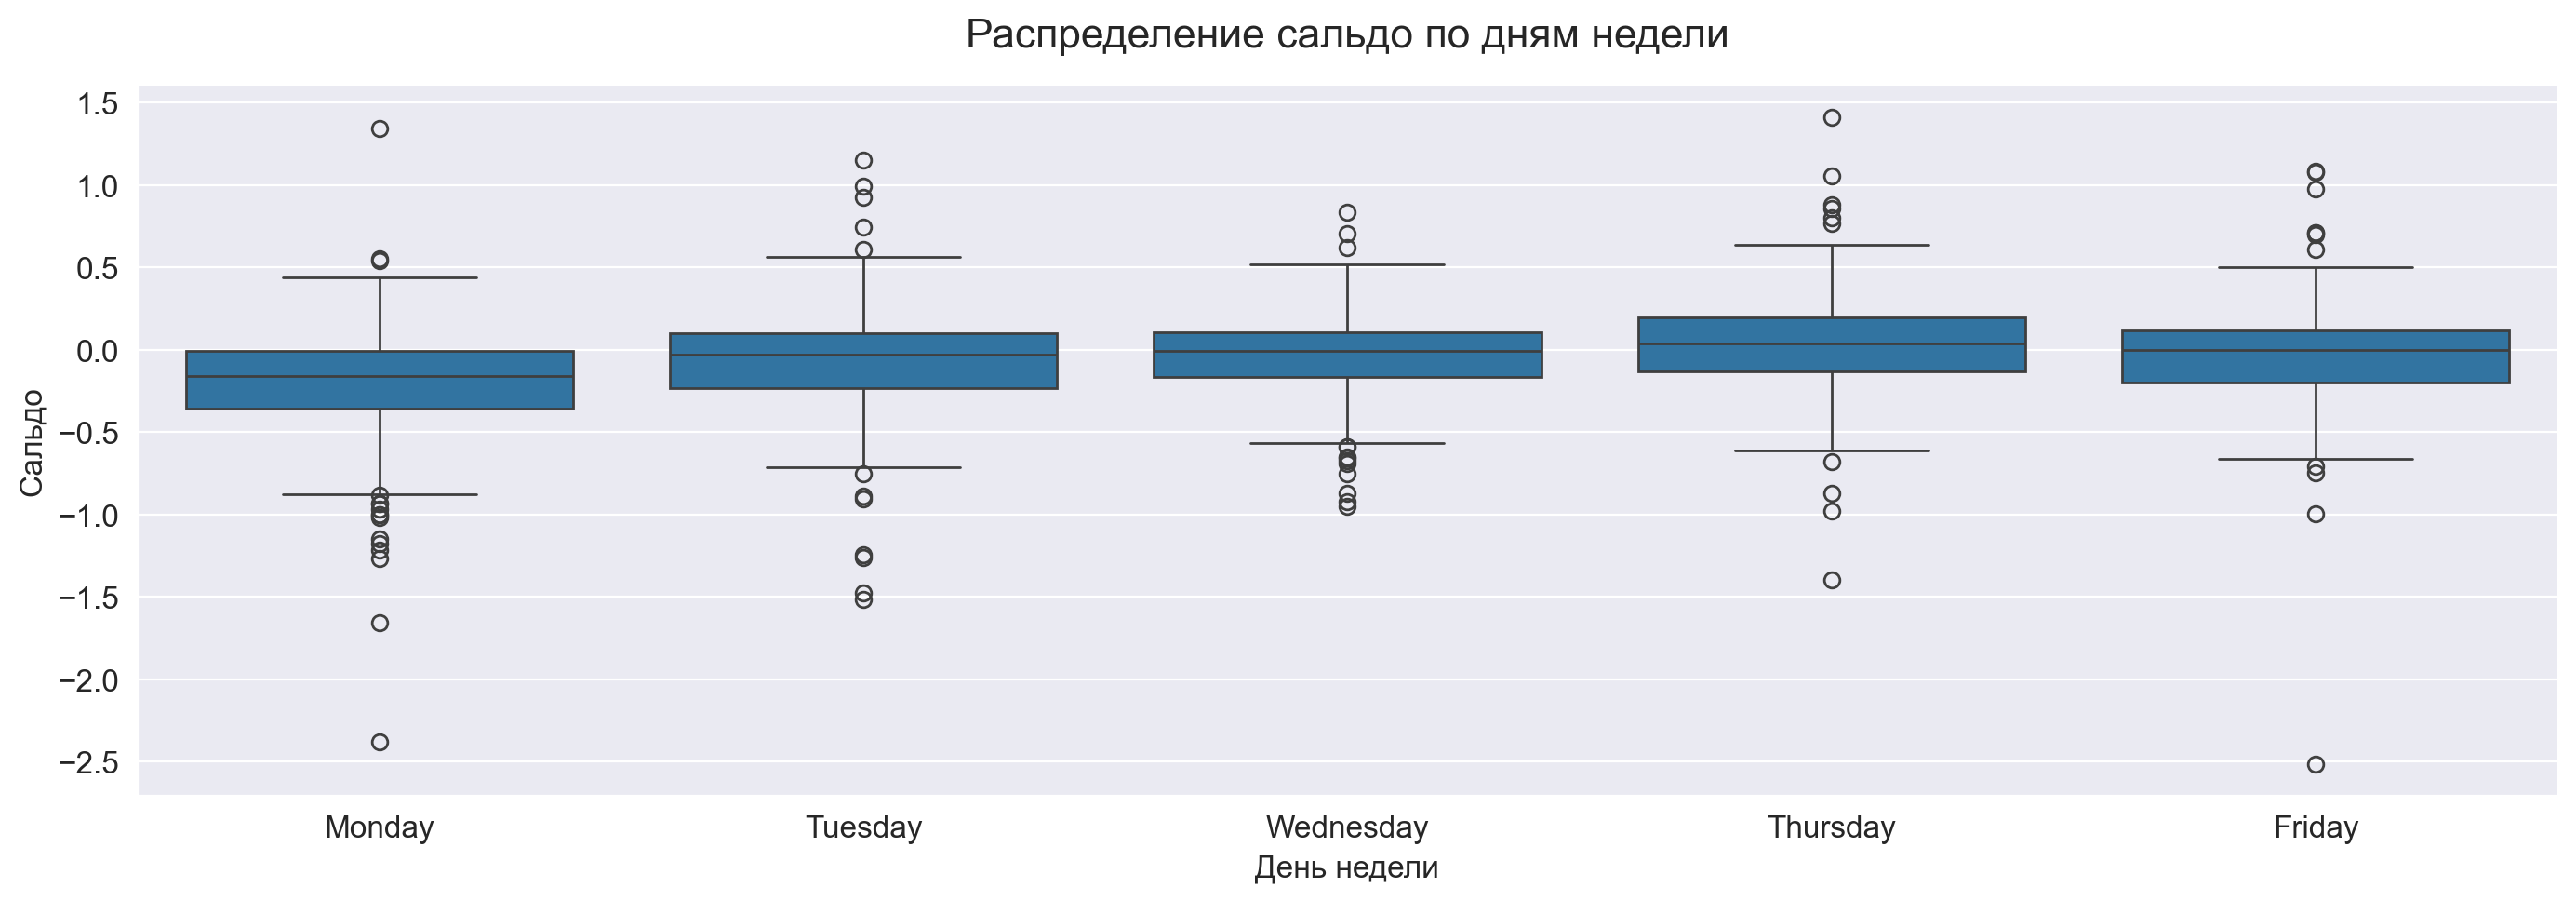

In [18]:
sns.boxplot(data=df, x="DayOfWeek", y="Balance")
plt.title("Распределение сальдо по дням недели", pad=15)
plt.xlabel("День недели")
plt.ylabel("Сальдо")
plt.tight_layout()
plt.show()

## На графиках видно, что сезонность в данных есть. Попробуем недельную сезонность: s = 5; 
## Сезонная компонента выглядит стабильной: D = 0; 
## Из графиков ACF и PACF пики на лагах 5, 10, 15. Попробуем P и Q равными 1

In [17]:
sarima_model, sarima_result, sarima_metrics = run_sarima(y_train=y_train, y_test=y_test, order=(1, 0, 1), seasonal_order=(1, 0, 1, 5))

sarima_metrics

{'MAE': 0.21699735300065195}

## При других комбинациях параметров получается хуже качество.
## Модель стала точнее

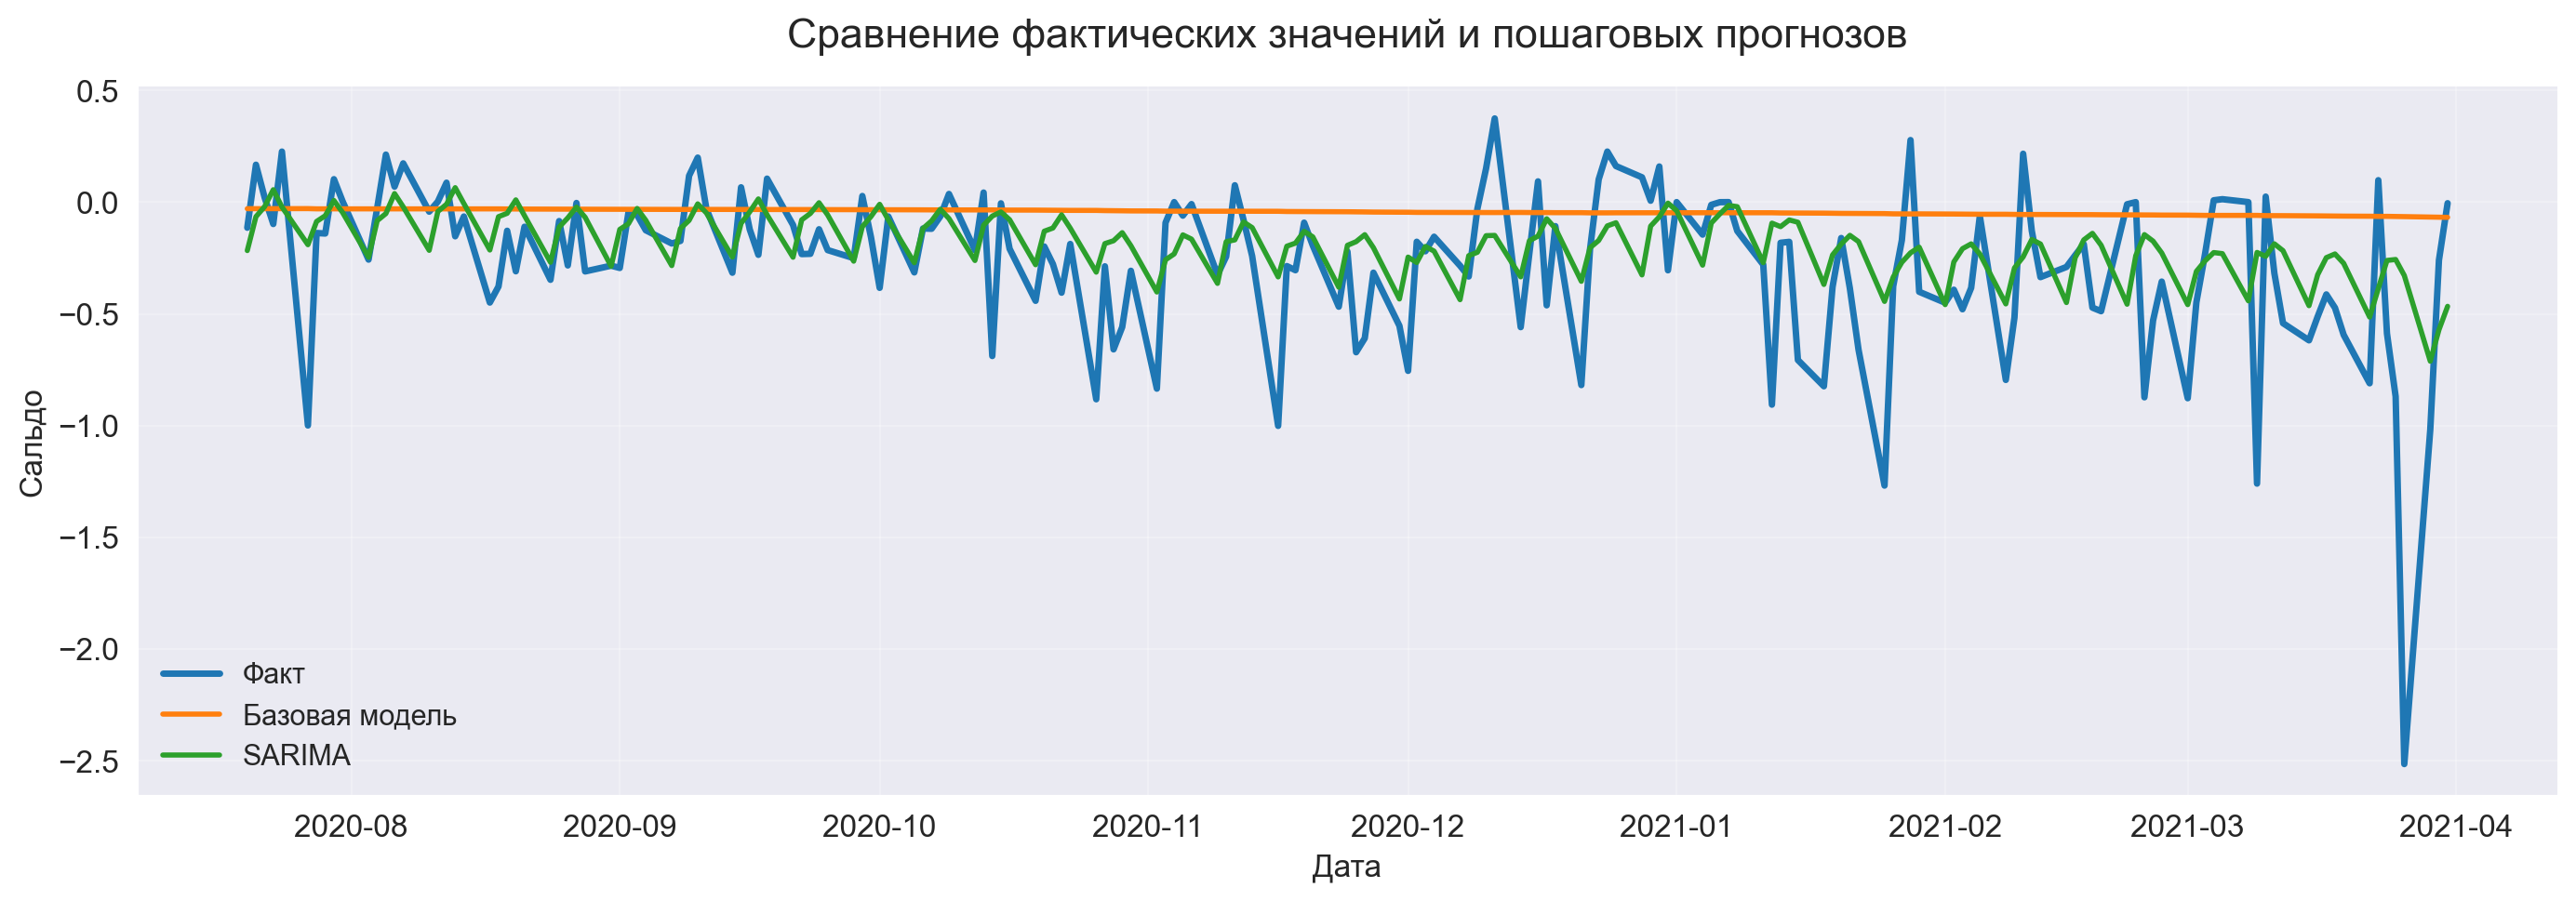

In [20]:
comparison_df = pd.DataFrame({
    "Факт": y_test.values,
    "Базовая модель": baseline_result["Predicted"].values,
    "SARIMA": sarima_result["Predicted"].values
}, index=y_test.index)

sns.lineplot(x=comparison_df.index, y=comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=comparison_df.index, y=comparison_df["Базовая модель"], label="Базовая модель", linewidth=2)
sns.lineplot(x=comparison_df.index, y=comparison_df["SARIMA"], label="SARIMA", linewidth=2)
plt.title("Сравнение фактических значений и пошаговых прогнозов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Модель SARIMA смогла выявить и воспроизвести сезонную компоненту временного ряда, что подтверждает наличие регулярной недельной структуры данных.

## Однако модель по-прежнему испытывает трудности при прогнозировании резких изменений и экстремальных значений ряда. Это может свидетельствовать о наличии сложных нелинейных зависимостей, которые плохо описываются линейными статистическими моделями.

## Полученные результаты обосновывают дальнейший переход к моделям машинного обучения с расширенным набором признаков.

# ML модели
### Были проверены две ансамблевые модели: случайный лес и Catboost (отличный отечественный аналог недружественным решениям)
### Для подбора гиперпараметров использовалась Optuna

In [24]:
# Генерация признаков
ml_data = create_features(df=df, target_col="Balance")

X, y, feature_cols = get_features_target(data=ml_data, target_col="Balance")

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество признаков: {len(feature_cols)}")

Размер матрицы признаков: (1083, 50)
Количество признаков: 50


In [25]:
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X))

train_idx, test_idx = splits[-1]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (903, 50)
Размер тестовой выборки: (180, 50)


## Случайный лес

In [28]:
rf_best_params, rf_best_score, rf_study = tune_random_forest(X=X_train, y=y_train, n_trials=30, n_splits=5)

print("Лучшие параметры случайного леса:")
print(rf_best_params)
print("\nЛучшее значение MAE на проверке:")
print(rf_best_score)

[I 2026-05-31 14:13:50,032] A new study created in memory with name: no-name-68f2141a-2a2b-4a85-a20a-e345863c9b79
[I 2026-05-31 14:13:50,959] Trial 0 finished with value: 0.2460093252192988 and parameters: {'n_estimators': 202, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.2460093252192988.
[I 2026-05-31 14:13:52,071] Trial 1 finished with value: 0.24247150530466133 and parameters: {'n_estimators': 255, 'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.24247150530466133.
[I 2026-05-31 14:13:54,045] Trial 2 finished with value: 0.2475784397287258 and parameters: {'n_estimators': 478, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.24247150530466133.
[I 2026-05-31 14:13:54,830] Trial 3 finished with value: 0.24583891365247248 and parameters: {'n_estimators': 147, 'max_depth':

Лучшие параметры случайного леса:
{'n_estimators': 446, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt'}

Лучшее значение MAE на проверке:
0.2409647458712878


In [29]:
# Обучение модели с лучшими параметрами
rf_model, rf_result, rf_metrics = run_random_forest(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, params=rf_best_params)

print(rf_metrics)

{'MAE': 0.22803217173757134}


## CatBoost

In [26]:
cat_best_params, cat_best_score, cat_study = tune_catboost(X=X_train, y=y_train, n_trials=30, n_splits=5)

print("Лучшие параметры CatBoost:")
print(cat_best_params)
print("\nЛучшее значение MAE на проверке:")
print(cat_best_score)

[I 2026-05-31 14:10:16,045] A new study created in memory with name: no-name-8c988196-4bdc-4fb0-91cd-cbdcf0a4a169
[I 2026-05-31 14:10:21,549] Trial 0 finished with value: 0.2436294835253813 and parameters: {'iterations': 669, 'depth': 7, 'learning_rate': 0.03216790667294638, 'l2_leaf_reg': 2.155017490625223, 'random_strength': 1.3655746287659487, 'bagging_temperature': 4.03776762184722}. Best is trial 0 with value: 0.2436294835253813.
[I 2026-05-31 14:10:22,096] Trial 1 finished with value: 0.2581760197273194 and parameters: {'iterations': 254, 'depth': 3, 'learning_rate': 0.15792322256141433, 'l2_leaf_reg': 4.280181234642823, 'random_strength': 3.3892821648292157, 'bagging_temperature': 3.4434174682749745}. Best is trial 0 with value: 0.2436294835253813.
[I 2026-05-31 14:10:24,157] Trial 2 finished with value: 0.26287304867363515 and parameters: {'iterations': 340, 'depth': 6, 'learning_rate': 0.1913467706347091, 'l2_leaf_reg': 6.961660076345162, 'random_strength': 1.1537194566676605,

Лучшие параметры CatBoost:
{'iterations': 663, 'depth': 7, 'learning_rate': 0.012130037348466563, 'l2_leaf_reg': 2.8928272143020353, 'random_strength': 1.633788807254053, 'bagging_temperature': 3.692679114280393}

Лучшее значение MAE на проверке:
0.2391206146938532


In [27]:
# Обучение модели с лучшими параметрами
cat_model, cat_result, cat_metrics = run_catboost(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, params=cat_best_params)

print(cat_metrics)

{'MAE': 0.21741874391571853}


## Сравнение прогнозов

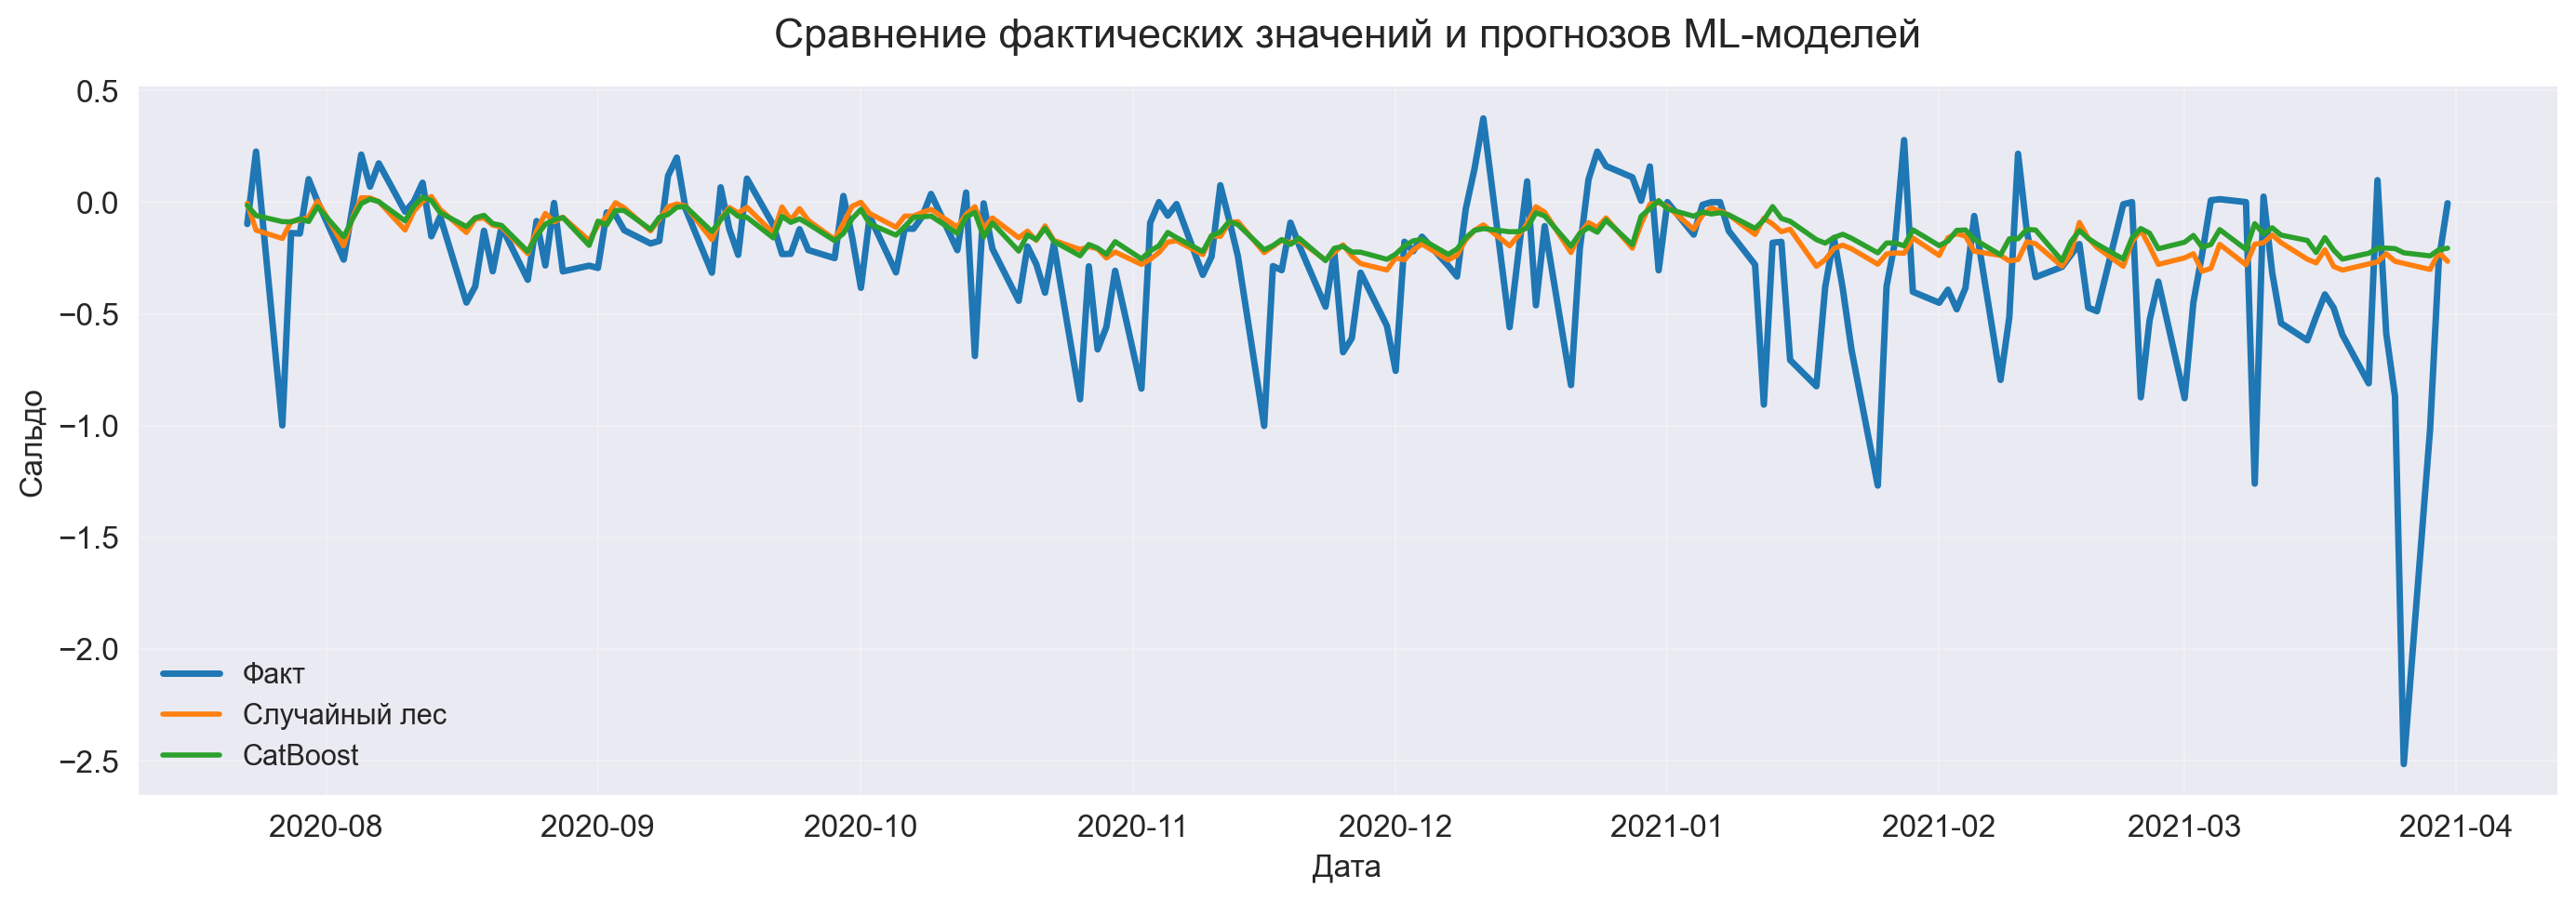

In [27]:
ml_comparison_df = pd.DataFrame({"Факт": y_test.values, "Случайный лес": rf_result["Predicted"].values, "CatBoost": cat_result["Predicted"].values}, index=ml_data.iloc[test_idx]["Date"])

sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["Случайный лес"], label="Случайный лес", linewidth=2)
sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["CatBoost"], label="CatBoost", linewidth=2)
plt.title("Сравнение фактических значений и прогнозов ML-моделей", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### ML модели получились лучше бейзлайна, но не лучше SARIMA

## Важность признаков

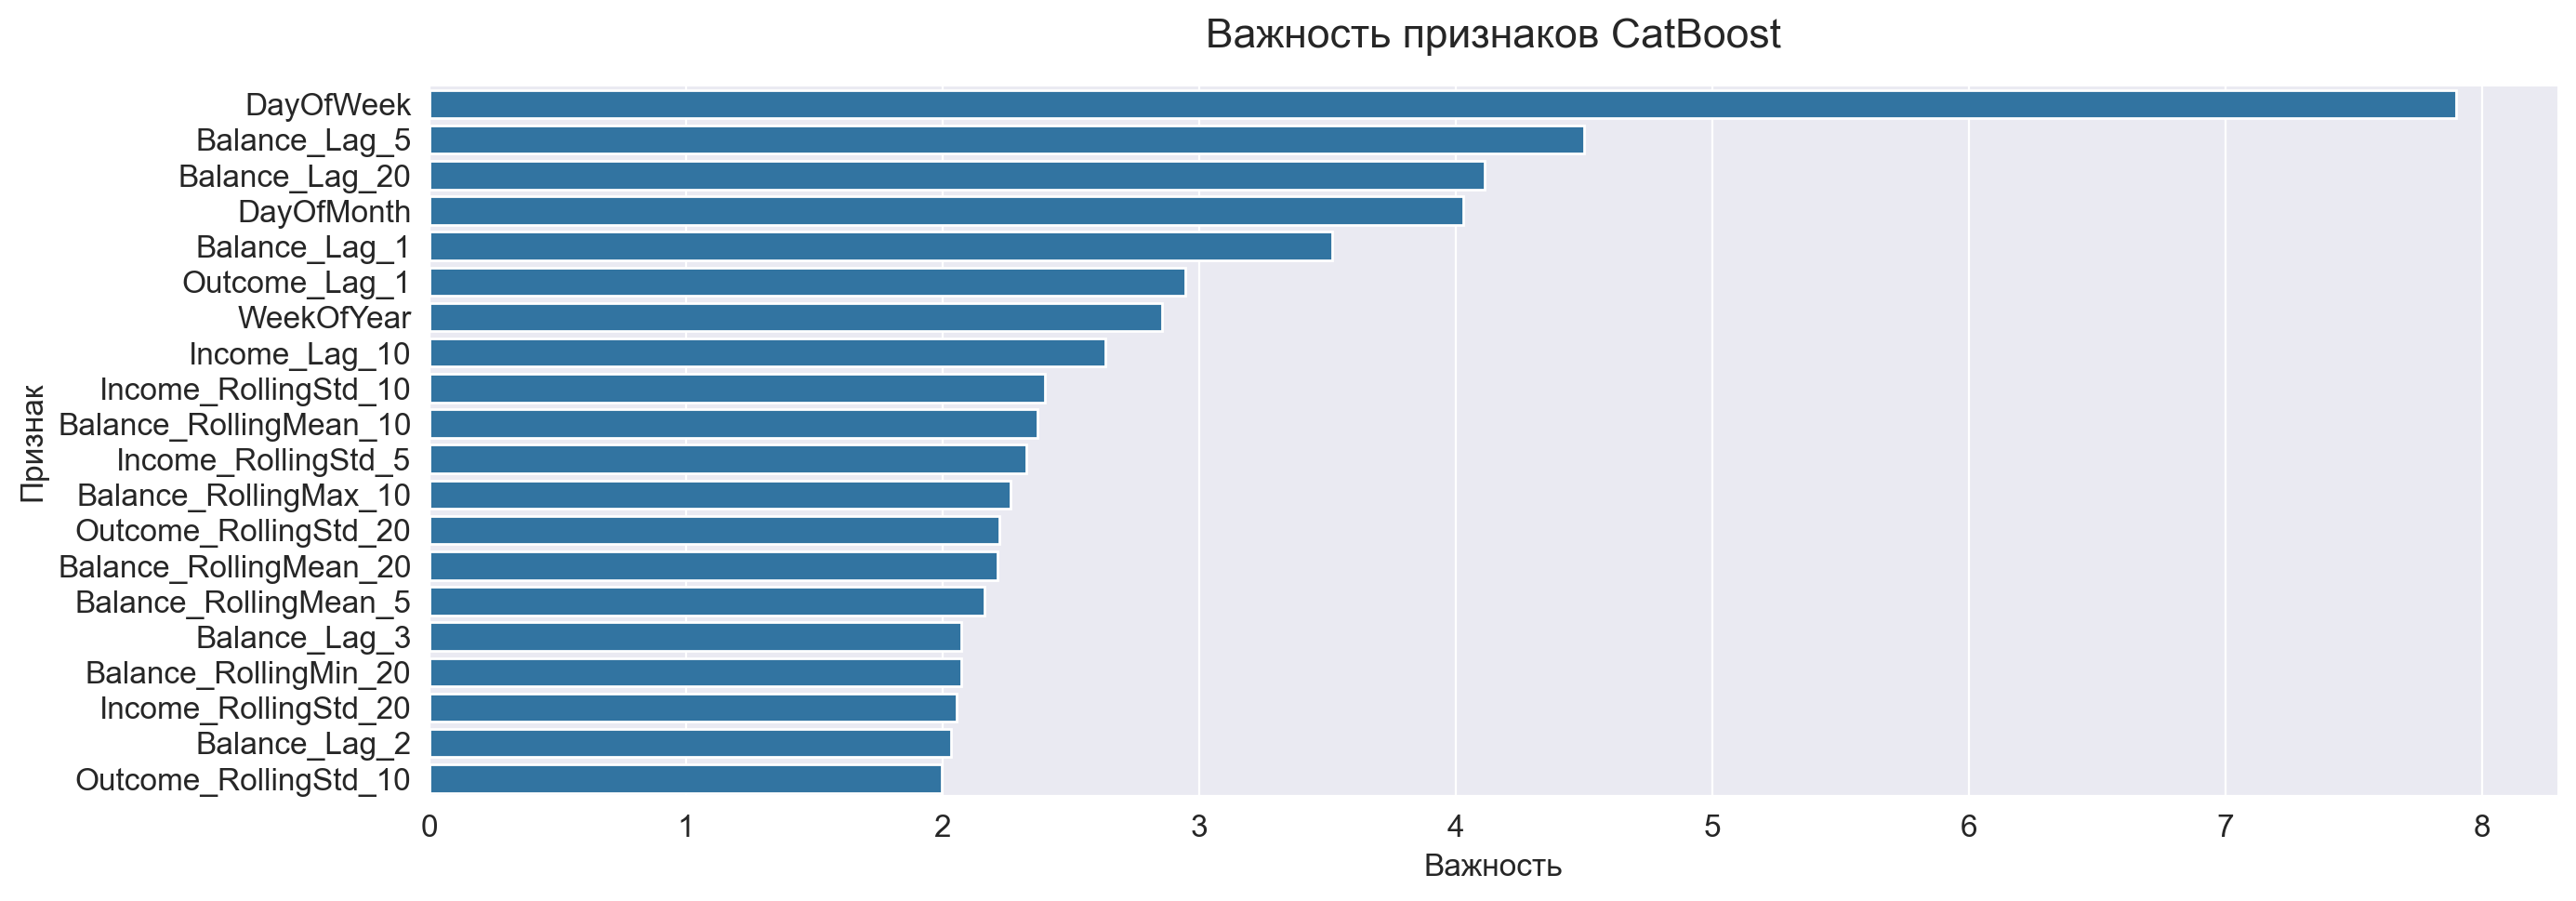

In [22]:
cat_importance_df = get_feature_importance(model=cat_model, feature_names=X_train.columns)

sns.barplot(data=cat_importance_df.head(20), x="Importance", y="Feature")
plt.title("Важность признаков CatBoost", pad=15)
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

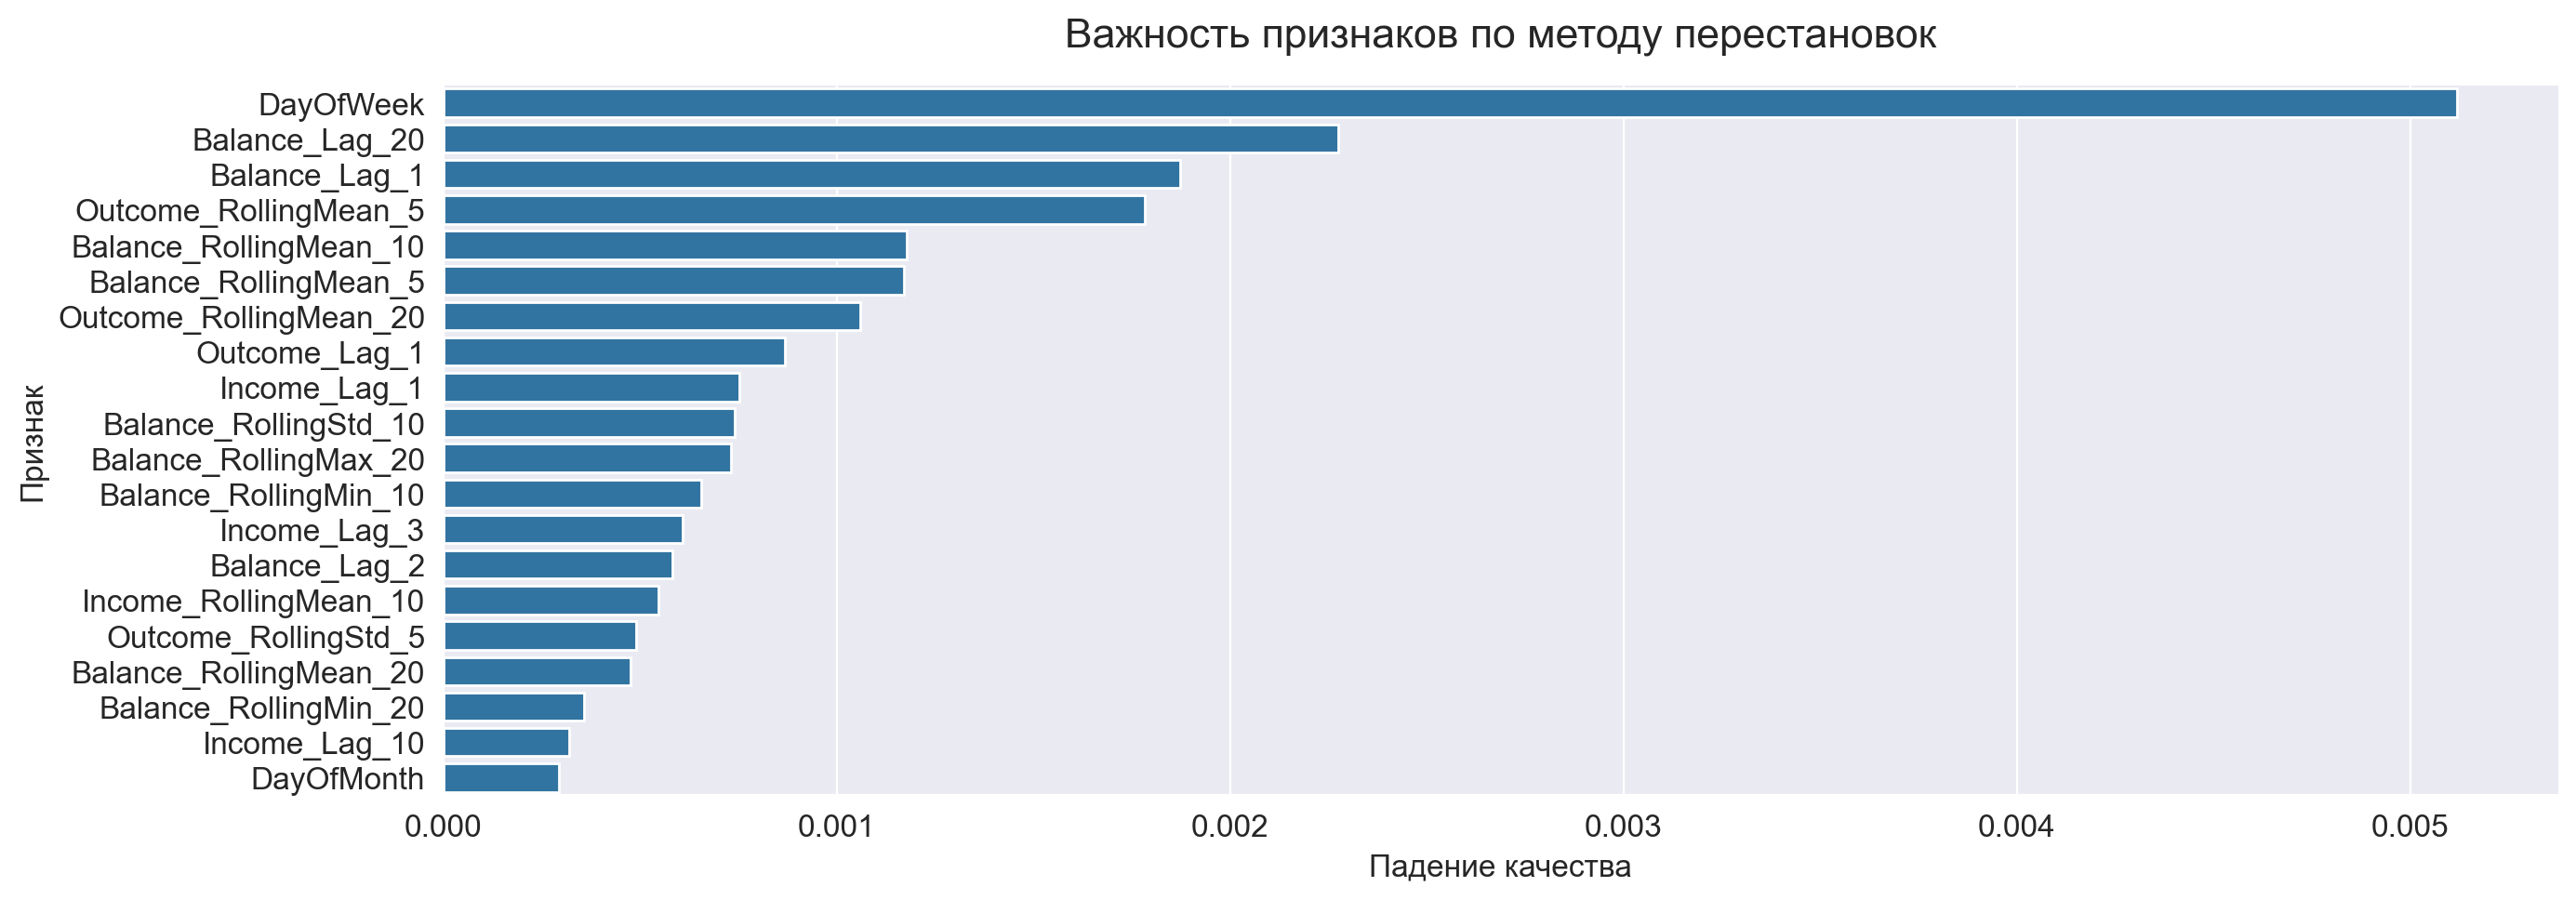

In [13]:
perm_importance_df = get_permutation_importance(model=cat_model, X=X_test, y=y_test, n_repeats=20)

sns.barplot(data=perm_importance_df.head(20), x="Importance", y="Feature")
plt.title("Важность признаков по методу перестановок", pad=15)
plt.xlabel("Падение качества")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

# Макрофакторы

## Исследованы курс рубль-доллар и ключевая ставка ЦБ

In [9]:
# Курс Рубль-Доллар
rub_usd = load_data("RUB_USD.xlsx", sheet_name="RC")

In [6]:
key_rate = save_key_rate_to_excel(
    start_date="09.01.2017",
    end_date="31.03.2021",
    file_name="KEY_RATE.xlsx",
    folder="data"
)

key_rate["KeyRate"] = key_rate["KeyRate"] / 100

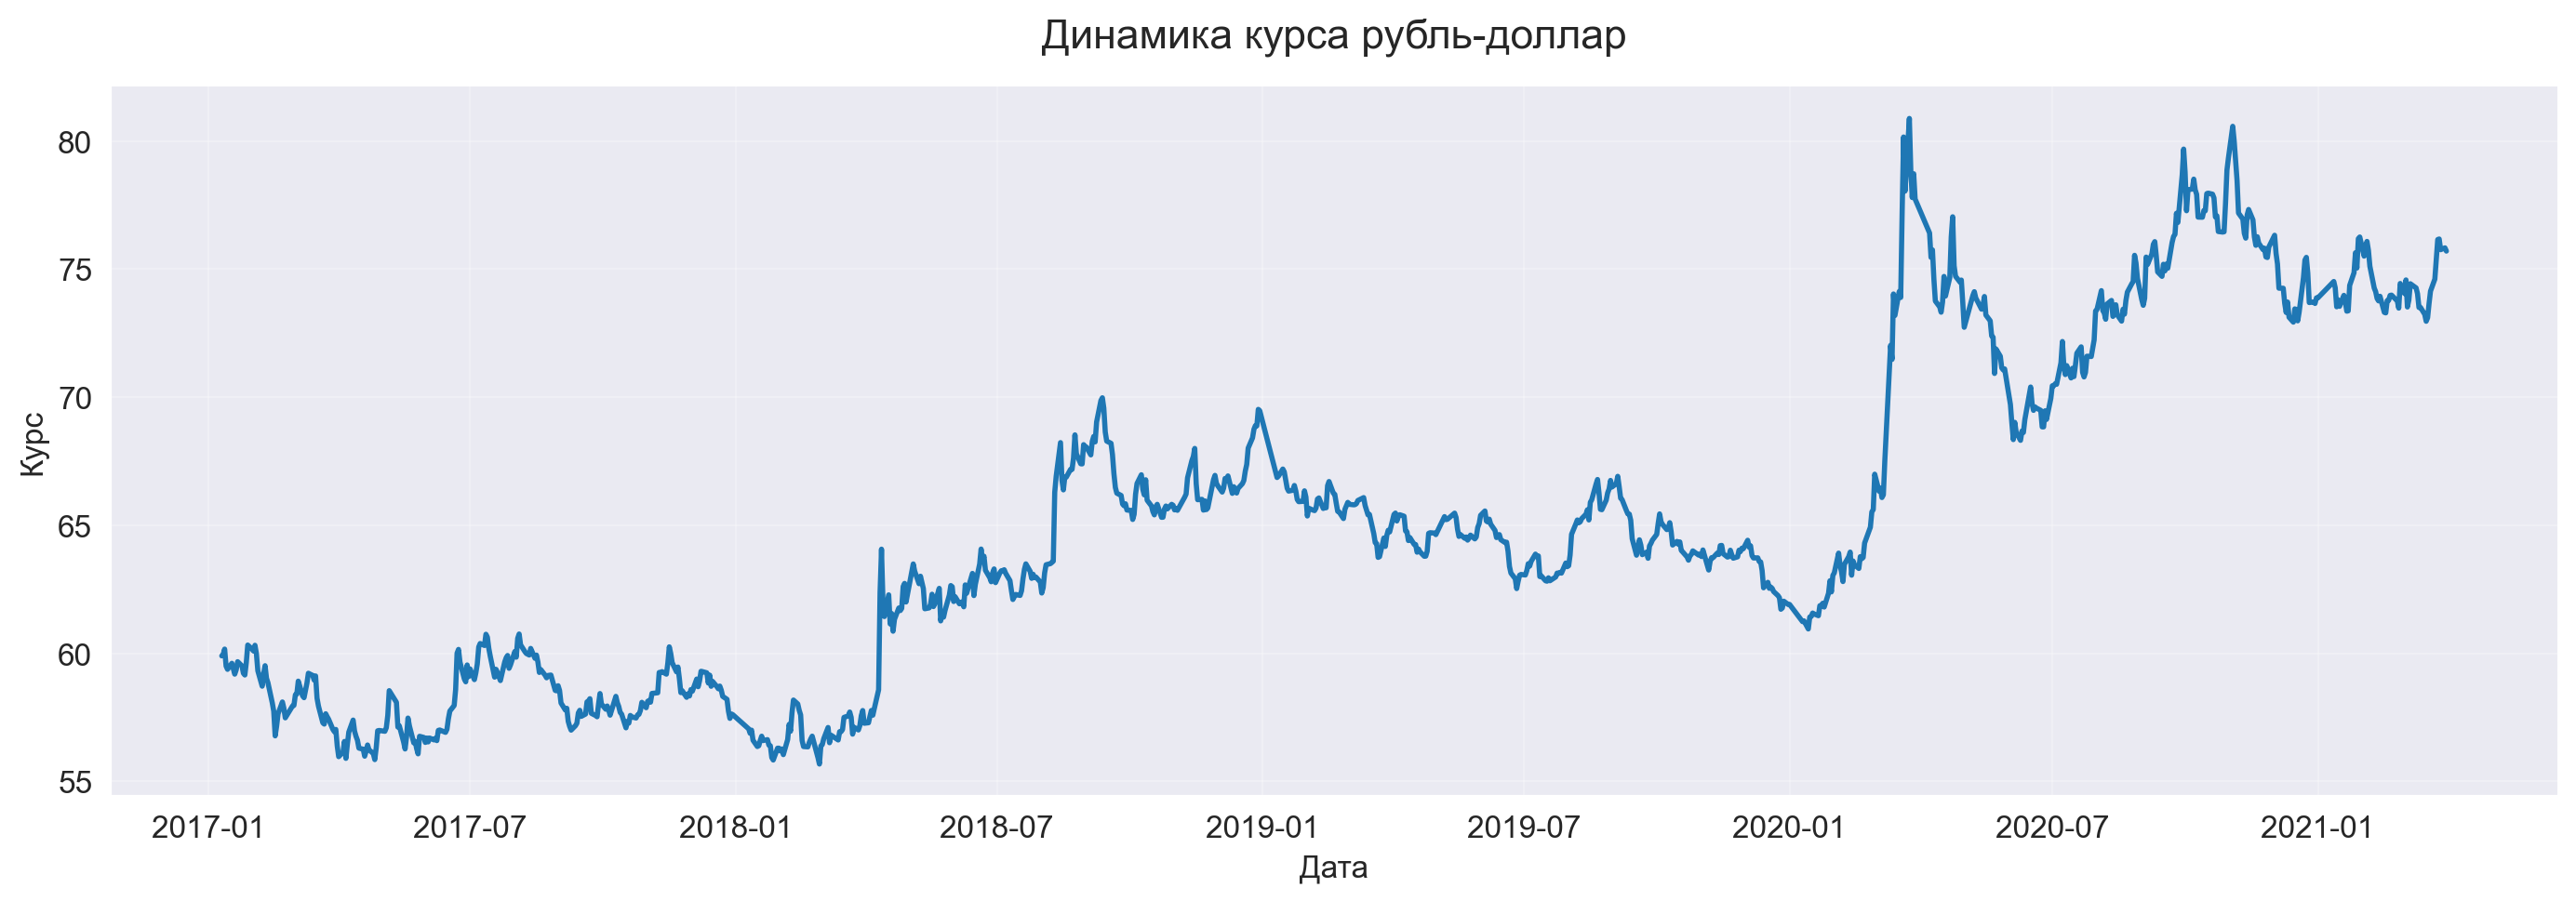

In [10]:
sns.lineplot(data=rub_usd, x="data", y="curs", linewidth=2)
plt.title("Динамика курса рубль-доллар", pad=15)
plt.xlabel("Дата")
plt.ylabel("Курс")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

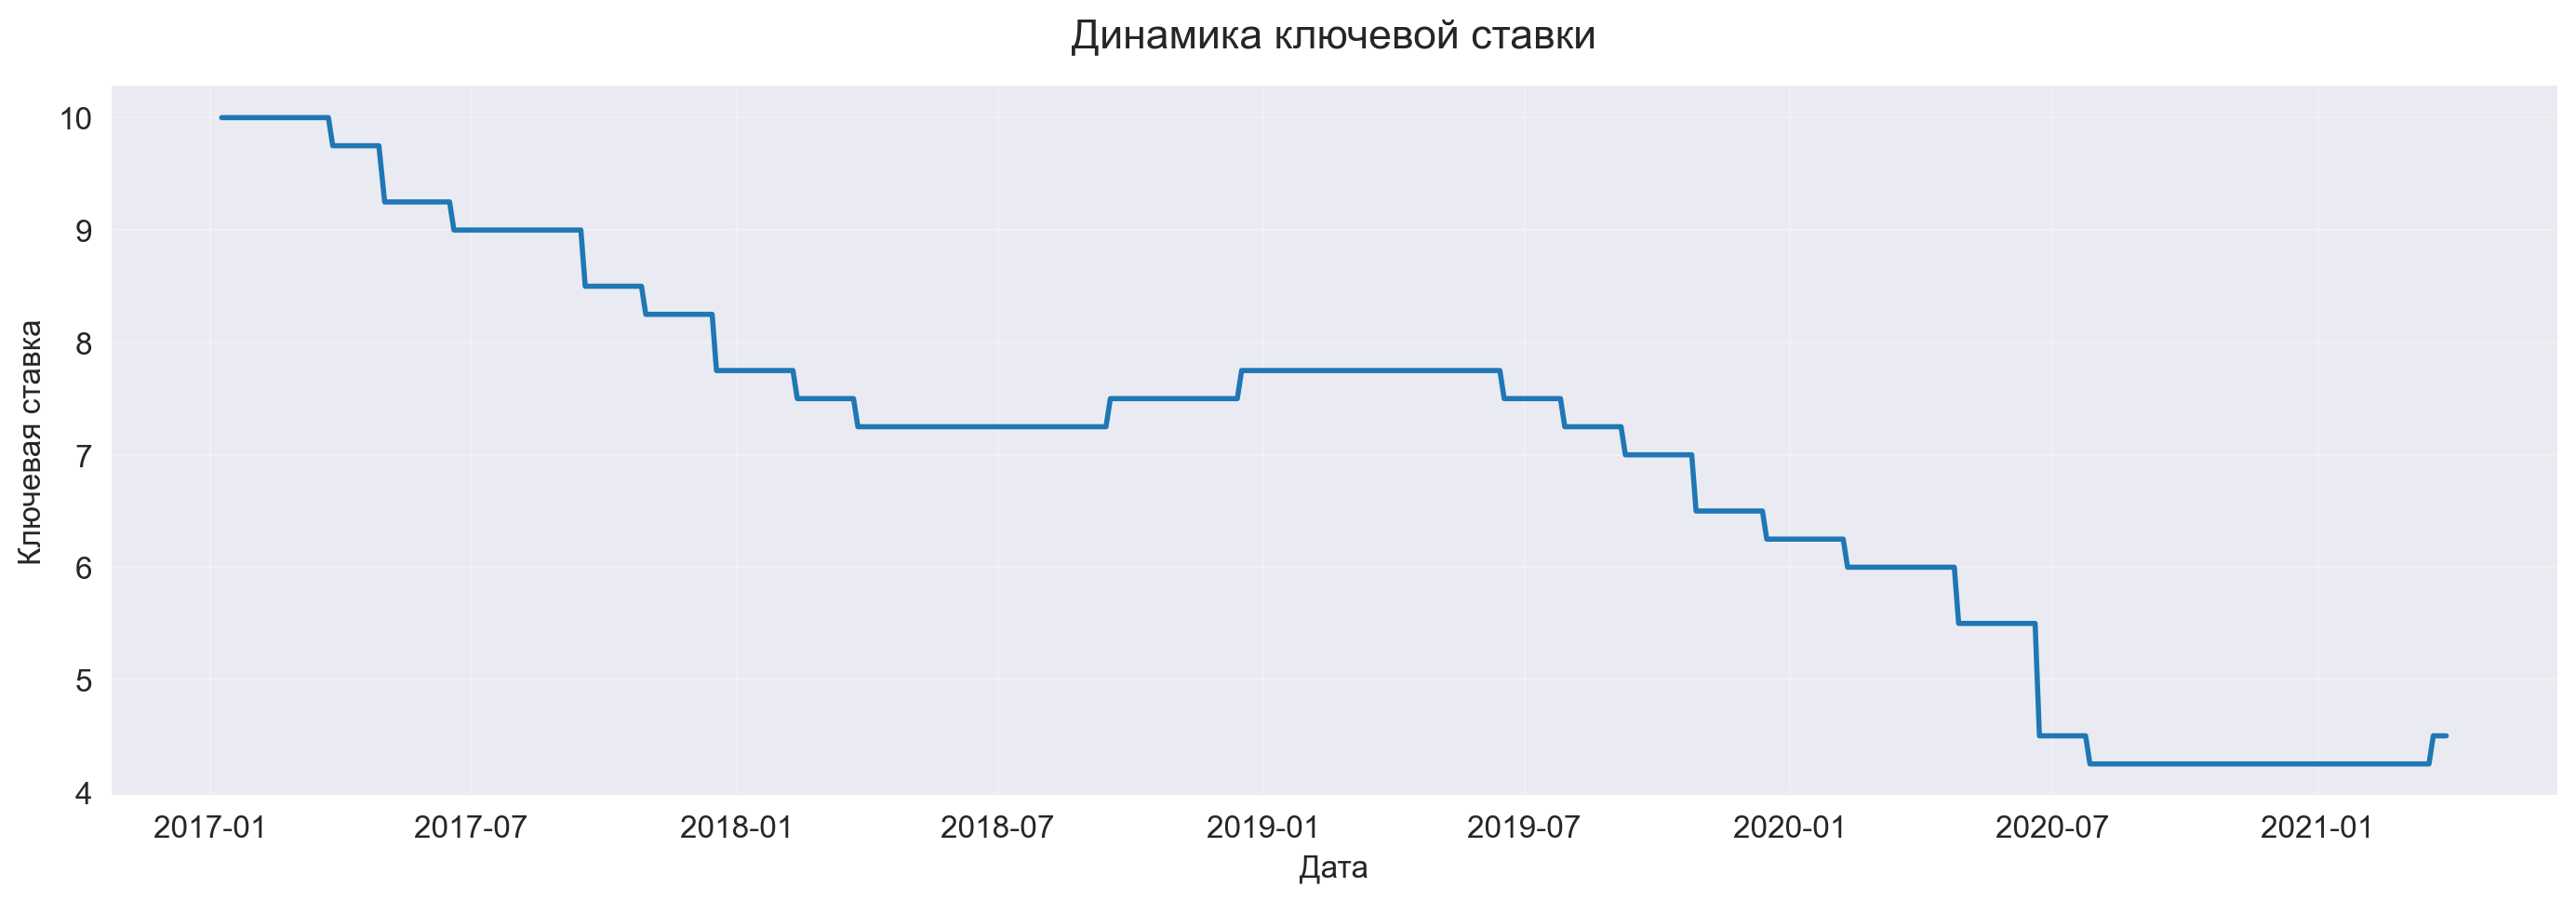

In [7]:
sns.lineplot(data=key_rate, x="Date", y="KeyRate", linewidth=2)
plt.title("Динамика ключевой ставки", pad=15)
plt.xlabel("Дата")
plt.ylabel("Ключевая ставка")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [12]:
ml_data_macro = create_features(df=df, rub_usd=rub_usd, key_rate=key_rate, target_col="Balance")

X_macro, y_macro, feature_cols_macro = get_features_target(data=ml_data_macro, target_col="Balance")

In [18]:
# Матрица коррелляций таргета от новых макрофичей
macro_cols = [
    "Balance",
    "USD_RUB_Lag_1",
    "USD_RUB_Lag_5",
    "USD_RUB_Lag_10",
    "USD_RUB_Change_1",
    "USD_RUB_Change_5",
    "KeyRate_Lag_1",
    "KeyRate_Lag_5",
    "KeyRate_Lag_20",
    "KeyRate_Change_1",
    "KeyRate_Change_5",
    "KeyRate_Change_20"
]

corr_matrix = ml_data_macro[macro_cols].corr()

corr_matrix

,Balance,USD_RUB_Lag_1,USD_RUB_Lag_5,USD_RUB_Lag_10,USD_RUB_Change_1,USD_RUB_Change_5,KeyRate_Lag_1,KeyRate_Lag_5,KeyRate_Lag_20,KeyRate_Change_1,KeyRate_Change_5,KeyRate_Change_20
Balance,1.000000,-0.210902,-0.211272,-0.221665,0.001377,-0.003570,0.247709,0.250005,0.252480,0.004458,-0.027936,-0.027630
USD_RUB_Lag_1,-0.210902,1.000000,0.984178,0.964078,0.054157,0.125396,-0.851815,-0.855821,-0.869652,0.041622,0.097828,0.175384
USD_RUB_Lag_5,-0.211272,0.984178,1.000000,0.980366,-0.035024,-0.035282,-0.845832,-0.849487,-0.863799,0.040485,0.091717,0.174569
USD_RUB_Lag_10,-0.221665,0.964078,0.980366,1.000000,-0.037304,-0.075790,-0.838479,-0.842758,-0.857680,0.045897,0.100844,0.185148
USD_RUB_Change_1,0.001377,0.054157,-0.035024,-0.037304,1.000000,0.444737,-0.027688,-0.028717,-0.027483,0.002591,0.014833,0.010715
USD_RUB_Change_5,-0.003570,0.125396,-0.035282,-0.075790,0.444737,1.000000,-0.060009,-0.061599,-0.058673,-0.006192,0.030004,0.002145
KeyRate_Lag_1,0.247709,-0.851815,-0.845832,-0.838479,-0.027688,-0.060009,1.000000,0.997902,0.991682,0.001478,0.003366,0.028799
KeyRate_Lag_5,0.250005,-0.855821,-0.849487,-0.842758,-0.028717,-0.061599,0.997902,1.000000,0.993178,-0.030456,-0.054280,0.001805
KeyRate_Lag_20,0.252480,-0.869652,-0.863799,-0.857680,-0.027483,-0.058673,0.991682,0.993178,1.000000,-0.025775,-0.058705,-0.096127
KeyRate_Change_1,0.004458,0.041622,0.040485,0.045897,0.002591,-0.006192,0.001478,-0.030456,-0.025775,1.000000,0.439065,0.205206


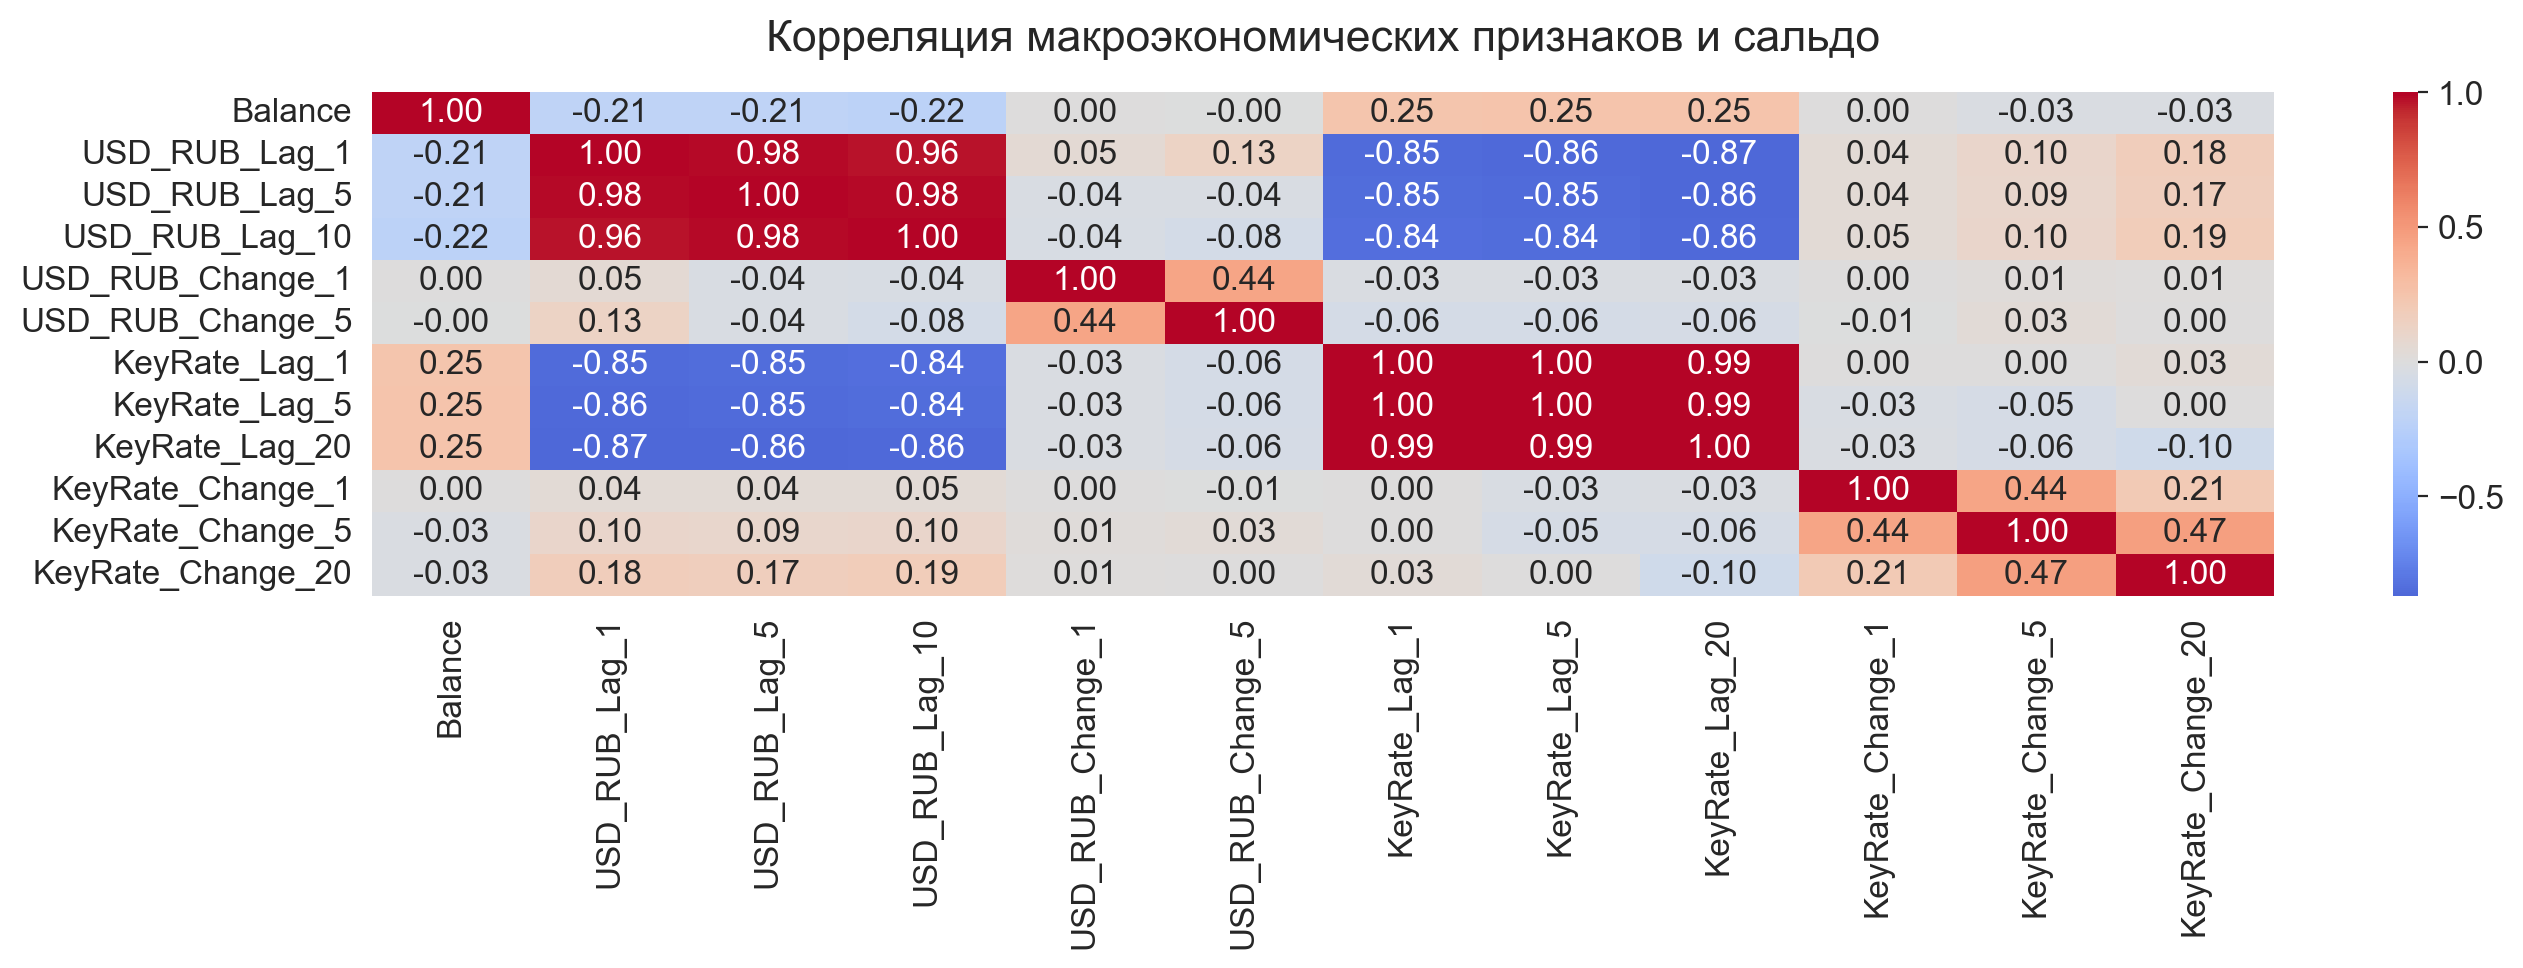

In [19]:
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция макроэкономических признаков и сальдо", pad=15)
plt.tight_layout()
plt.show()

Таргет слабо слабо коррелирует с новыми фичами

In [17]:
tscv_macro = TimeSeriesSplit(n_splits=5)
splits_macro = list(tscv_macro.split(X_macro))

train_idx_macro, test_idx_macro = splits_macro[-1]

X_train_macro = X_macro.iloc[train_idx_macro]
X_test_macro = X_macro.iloc[test_idx_macro]

y_train_macro = y_macro.iloc[train_idx_macro]
y_test_macro = y_macro.iloc[test_idx_macro]

print(f"Размер обучающей выборки: {X_train_macro.shape}")
print(f"Размер тестовой выборки: {X_test_macro.shape}")

Размер обучающей выборки: (902, 65)
Размер тестовой выборки: (180, 65)


In [20]:
cat_best_params_macro, cat_best_score_macro, cat_study_macro = tune_catboost(X=X_train_macro, y=y_train_macro, n_trials=30, n_splits=5)

print("Лучшие параметры CatBoost:")
print(cat_best_params_macro)
print("\nЛучшее значение MAE на проверке:")
print(cat_best_score_macro)

[I 2026-05-31 14:53:21,632] A new study created in memory with name: no-name-27a62ab9-fd66-481e-a50b-172425bc7f74
[I 2026-05-31 14:53:23,737] Trial 0 finished with value: 0.26433112902866307 and parameters: {'iterations': 408, 'depth': 5, 'learning_rate': 0.18088156896670504, 'l2_leaf_reg': 8.4825978275634, 'random_strength': 3.5066389908479243, 'bagging_temperature': 0.9622492003121524}. Best is trial 0 with value: 0.26433112902866307.
[I 2026-05-31 14:53:26,602] Trial 1 finished with value: 0.24147102698183462 and parameters: {'iterations': 388, 'depth': 6, 'learning_rate': 0.01790052321669643, 'l2_leaf_reg': 2.3093083915060726, 'random_strength': 0.5206991474116561, 'bagging_temperature': 3.6971103944106574}. Best is trial 1 with value: 0.24147102698183462.
[I 2026-05-31 14:53:29,272] Trial 2 finished with value: 0.2802214601945322 and parameters: {'iterations': 769, 'depth': 4, 'learning_rate': 0.1851635585985281, 'l2_leaf_reg': 1.4093510239701725, 'random_strength': 2.926616546870

Лучшие параметры CatBoost:
{'iterations': 647, 'depth': 8, 'learning_rate': 0.011365180001411545, 'l2_leaf_reg': 5.406836239738223, 'random_strength': 0.15324985602468555, 'bagging_temperature': 4.446194645362494}

Лучшее значение MAE на проверке:
0.23380561134549444


In [22]:
# Обучение модели с лучшими параметрами
cat_model_macro, cat_result_macro, cat_metrics_macro = run_catboost(X_train=X_train_macro, y_train=y_train_macro, X_test=X_test_macro, y_test=y_test_macro, params=cat_best_params_macro)

print(cat_metrics_macro)

{'MAE': 0.24260831875792338}


### Точность лучше не стала

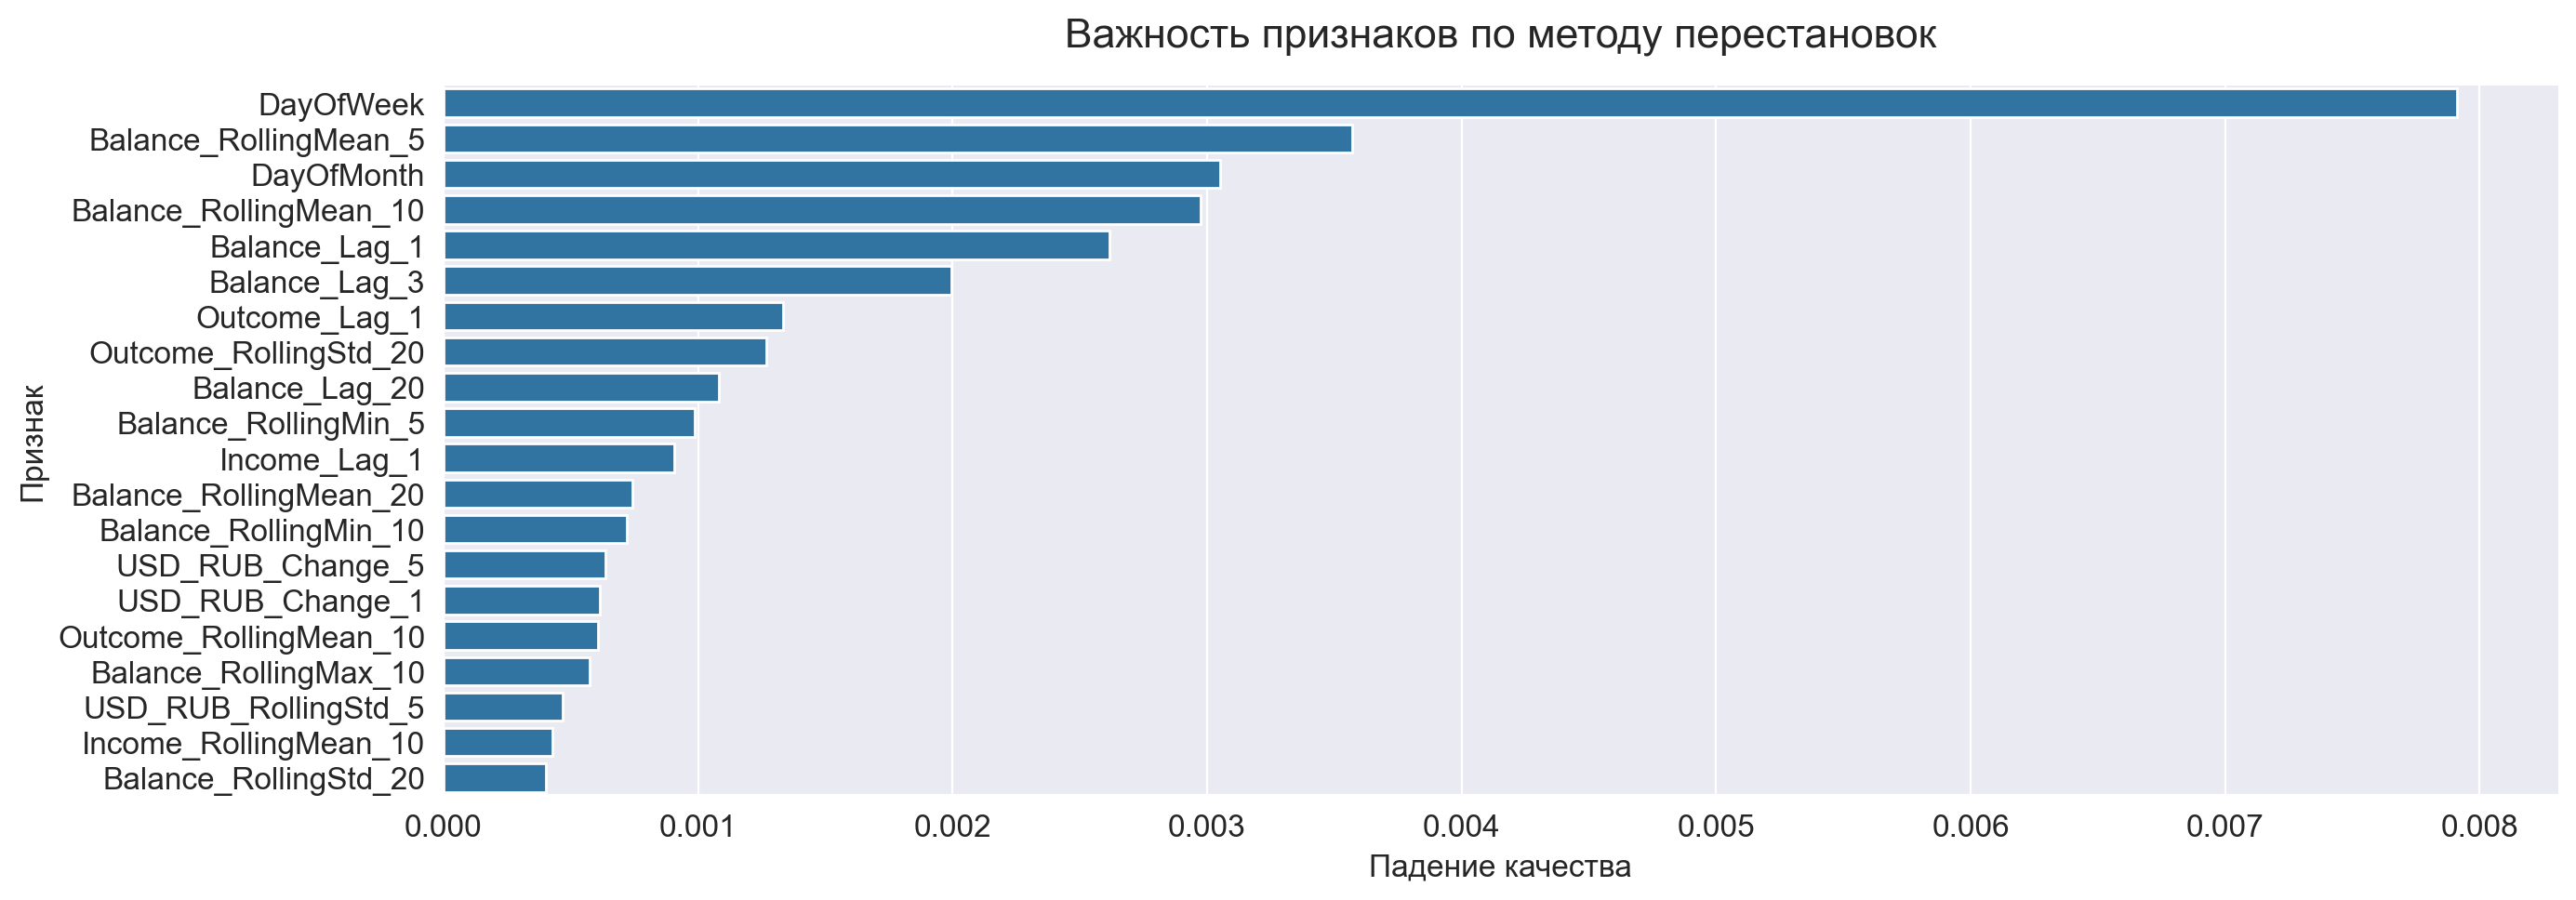

In [23]:
perm_importance_df_macro = get_permutation_importance(model=cat_model_macro, X=X_test_macro, y=y_test_macro, n_repeats=20)

sns.barplot(data=perm_importance_df_macro.head(20), x="Importance", y="Feature")
plt.title("Важность признаков по методу перестановок", pad=15)
plt.xlabel("Падение качества")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

# Отбор признаков (для модели CatBoost)

In [14]:
# Базовая модель
base_model = CatBoostRegressor(random_seed=42, verbose=False, loss_function="MAE", **cat_best_params)

top_n = 20

In [15]:
# Фильтрационный метод: корреляция
corr_features, corr_scores = select_by_correlation(X=X_train, y=y_train, top_n=top_n)

corr_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=corr_features
)

corr_mae

0.227680530574662

In [16]:
# Фильтрационный метод: взаимная информация
mi_features, mi_scores = select_by_mutual_information(
    X=X_train,
    y=y_train,
    top_n=top_n
)

mi_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=mi_features
)

mi_mae

0.22653388023754478

In [17]:
# Встроенный метод: Lasso
lasso_features, lasso_scores = select_by_lasso(X=X_train, y=y_train, top_n=top_n)

lasso_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=lasso_features
)

lasso_mae

0.2305455281902022

In [19]:
# Оберточный метод: permutation importance
perm_features, perm_scores = select_by_permutation(
    model=cat_model,
    X=X_test,
    y=y_test,
    top_n=top_n
)

perm_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=perm_features
)

perm_mae

0.21795513075020082

In [21]:
selection_results = pd.DataFrame({
    "Метод": [
        "Все признаки",
        "Корреляция",
        "Mutual Information",
        "Lasso",
        "Permutation Importance"
    ],
    "Категория": [
        "Без отбора",
        "Фильтрационный",
        "Фильтрационный (нелинейный)",
        "Встроенный",
        "Оберточный"
    ],
    "Количество признаков": [
        X_train.shape[1],
        len(corr_features),
        len(mi_features),
        len(lasso_features),
        len(perm_features)
    ],
    "MAE": [
        cat_metrics["MAE"],
        corr_mae,
        mi_mae,
        lasso_mae,
        perm_mae
    ]
})

selection_results

,Метод,Категория,Количество признаков,MAE
0,Все признаки,Без отбора,50,0.232034
1,Корреляция,Фильтрационный,20,0.227681
2,Mutual Information,Фильтрационный (нелинейный),20,0.226534
3,Lasso,Встроенный,14,0.230546
4,Permutation Importance,Оберточный,20,0.217955


In [22]:
tscv = TimeSeriesSplit(n_splits=5)

corr_selected_sets = []
lasso_selected_sets = []
perm_selected_sets = []
mi_selected_sets = []

for train_idx, valid_idx in tscv.split(X_train):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_valid = X_train.iloc[valid_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    corr_features_fold, _ = select_by_correlation(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    mi_features_fold, _ = select_by_mutual_information(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    lasso_features_fold, _ = select_by_lasso(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    fold_model = CatBoostRegressor(
        random_seed=42,
        verbose=False,
        loss_function="MAE",
        **cat_best_params
    )

    fold_model.fit(X_fold_train, y_fold_train)

    perm_features_fold, _ = select_by_permutation(
        model=fold_model,
        X=X_fold_valid,
        y=y_fold_valid,
        top_n=top_n
    )

    corr_selected_sets.append(corr_features_fold)
    mi_selected_sets.append(mi_features_fold)
    lasso_selected_sets.append(lasso_features_fold)
    perm_selected_sets.append(perm_features_fold)


stability_results = pd.DataFrame({

    "Метод": [
        "Корреляция",
        "Mutual Information",
        "Lasso",
        "Permutation Importance"

    ],

    "Категория": [
        "Фильтрационный",
        "Фильтрационный (нелинейный)",
        "Встроенный",
        "Оберточный"
    ],

    "Индекс Кунчевой": [
        average_kuncheva(corr_selected_sets, X_train.shape[1]),
        average_kuncheva(mi_selected_sets, X_train.shape[1]),
        average_kuncheva(lasso_selected_sets, X_train.shape[1]),
        average_kuncheva(perm_selected_sets, X_train.shape[1])
    ]

})

stability_results

,Метод,Категория,Индекс Кунчевой
0,Корреляция,Фильтрационный,0.141667
1,Mutual Information,Фильтрационный (нелинейный),0.441667
2,Lasso,Встроенный,0.079676
3,Permutation Importance,Оберточный,0.083333


In [23]:
final_selection_summary = selection_results.merge(stability_results, on=["Метод", "Категория"], how="left")

final_selection_summary

,Метод,Категория,Количество признаков,MAE,Индекс Кунчевой
0,Все признаки,Без отбора,50,0.232034,NaN
1,Корреляция,Фильтрационный,20,0.227681,0.141667
2,Mutual Information,Фильтрационный (нелинейный),20,0.226534,0.441667
3,Lasso,Встроенный,14,0.230546,0.079676
4,Permutation Importance,Оберточный,20,0.217955,0.083333


### Лучший метод по качеству - Permutation Importance
### Лучший метод по стабильности - Mutual Information

# Дообучение моделей